In [30]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
plt.rcParams['text.usetex'] = False
plt.style.use('seaborn-v0_8-colorblind')
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.right'] = False

In [31]:
results = pd.read_csv("wandb_export.csv")
df = results[results['State'] == 'finished']

Processing common to all analysis.

In [237]:
results = pd.read_csv("results.csv")
# results = pd.read_csv("wandb_export.csv")
df = results[results['State'] == 'finished']
df = df[
    ["model.name", "model.aggregation", "model.alpha_scalar", "dataset.modalities_order"] + [col for col in df.columns if "final_scores" in col] + [col for col in df.columns if "fid" in col] +
      [col for col in df.columns if "val/loss/rec_loss" in col] +
       [col for col in df.columns if "val/conditional_generation" in col]
] 
df["model.alpha_scalar"] = df["model.alpha_scalar"].fillna(0.0)
# update names
old_name = df['model.name'] + df['model.aggregation']
new_name = old_name.str.replace("jointavg", "AVG", regex=False)
new_name = new_name.str.replace("jointprior", "JP", regex=False)
new_name = new_name.str.replace("joint", "", regex=False)
new_name = new_name.str.replace("avg", "", regex=False)
new_name = new_name.str.replace("moe", "MoE", regex=False)
new_name = new_name.str.replace("mopoe", "MoPoE", regex=False)
new_name = new_name.str.replace("mixedprior", "MMVM", regex=False)
new_name = new_name.str.replace("unimodal", "independent", regex=False)
df.loc[:, 'model.name'] = new_name
df["dataset.modalities_order"] = [int(res[0]) if len(res) == 1 else 
                                           int(res[1]) for res in df["dataset.modalities_order"].fillna('0')]

views = ["m0", "m1", "m2", "m3", "m4"]
relationships = []
indiv_results = []
one_to_one = []
column_names = []
for view_a in views:
  view_a_list = []
  one_to_one.append(view_a + "_to_" + view_a)
  for view_b in views:
    relationships.append(view_a + "_to_" + view_b)
    if view_a != view_b:
      view_a_list.append(view_b + "_to_" + view_a)
  indiv_results.append(view_a_list) # store view_a list
  column_names.append(str(view_a))
  indiv_results.append([view + "_cov" for view in view_a_list])
  column_names.append(str(view_a) + "_cov")
    
indiv_results.append(one_to_one)
column_names.append("one_to_one")
indiv_results.append([rel + "_cov" for rel in one_to_one])
column_names.append("one_to_one_cov")

relationships_full = ["final_scores/coherence/" + rel for rel in relationships]
cov_better = []
for rel in relationships_full:
  cov_better.append((df[rel] < df[rel + "_cov"]))
df['cov_better'] = np.mean(np.array(cov_better), axis = 0)
metric_cols = [c for c in df.columns if "final_scores/coherence/m" in c]
metric_cols_cov = [c for c in metric_cols if "cov" in c]
metric_cols = [c for c in metric_cols if "cov" not in c]

Make copies of the datasets

In [238]:
df_alpha = df.copy()
df_alpha = df_alpha[(df_alpha["dataset.modalities_order"] == 0) & ((df_alpha["model.name"] == "JP" )| (df_alpha["model.name"] == "independent" ))]
# add
df_modality = df.copy()
df_modality = df_modality[df_modality["model.alpha_scalar"] == 0.97]
df_comparison = df.copy()
# subset to only include alpha = 0.97 or all models except JP
df_comparison = df_comparison[((df_comparison["model.alpha_scalar"] == 0.97) & (df_comparison["dataset.modalities_order"] == 0)) | (df_comparison["model.name"] != "JP")]


In [64]:
df_alpha_og = df_alpha.copy()

# $\alpha$ plots

In [34]:
df_subset = df_alpha.fillna(-1)
df_subset.loc[df_subset['model.name']== 'independent', 'model.alpha_scalar'] = 0
df_subset = df_subset[df_subset["model.alpha_scalar"] != -1]
df_subset['model.name'] = df_subset['model.name'] + ["-" + str(x) for x in df_subset['model.alpha_scalar']]
df_subset['model.name'] = [str(x) for x in df_subset['model.alpha_scalar']]
df_subset = df_subset[df_subset["dataset.modalities_order"] == 0]
model_means_jp = df_subset.groupby("model.name")[metric_cols].mean()
model_means_jp_cov = df_subset.groupby("model.name")[metric_cols_cov].mean()


### Functions

In [113]:

def extract_matrix(avg_series, cov=False):
    """Convert a row of averaged metrics into a square DataFrame."""
    tmp = avg_series.to_frame("value")
    if cov == False:
      ex = tmp.index.to_series().str.extract(r"m(\d+)_to_m(\d+)")
    else:
      ex = tmp.index.to_series().str.extract(r"m(\d+)_to_m(\d+)_cov")
    tmp["from"]   = "M" + ex[0].astype(str)
    tmp["to"] = "M" + ex[1].astype(str)
    tmp = tmp.dropna(subset=["to", "from"])
    return tmp.pivot(index="to", columns="from", values="value")

def produce_alpha_plots(matrices, filename, v_min=0, v_max=1,color_map='viridis', text_color='w', n_rows=3, n_cols=4, overall_title="Coherence"):
    """
    Plot up to 10 heatmaps on a 3x4 grid, with the last two centered on the bottom row.
    Unused subplots are hidden.
    """
    n_models = len(matrices)
    output_path = Path(filename)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    if n_models == 2:
        with plt.rc_context({'text.usetex': False}):
            fig, axes = plt.subplots(1, 2, figsize=(5 * n_cols, 4 * n_rows))
            axes = np.atleast_1d(axes)
            for ax, (name, mat) in zip(axes, matrices.items()):
                data = mat.values
                im = ax.imshow(data, cmap=color_map, vmin=v_min, vmax=v_max, interpolation='none')
                ax.set_title(f"{name}", fontsize=12)
                ax.set_xlabel("First modality")
                ax.set_ylabel("Conditionally imputed view")
                ax.set_xticks(np.arange(len(mat.columns)))
                ax.set_yticks(np.arange(len(mat.index)))
                ax.set_xticklabels(mat.columns)
                ax.set_yticklabels(mat.index)
                ax.spines[['right', 'top']].set_visible(True)
                plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
                ax.grid(False)

                for i in range(len(mat.index)):
                    for j in range(len(mat.columns)):
                        ax.text(j, i, f"{data[i, j]:.2f}", ha="center", va="center", color=text_color, fontsize=8)

            cbar = fig.colorbar(im, ax=axes, orientation='horizontal', fraction=0.05, pad=0.08, aspect=30)
            cbar.set_label(overall_title, fontsize=12)
            cbar.ax.set_position([0.3, -0.1, 0.4, 0.03])
            plt.subplots_adjust(wspace=0.2, hspace=0.35)
            # plt.margins(x=-0.3, y=-0.3)
  
            fig.savefig(output_path, bbox_inches='tight')
            plt.show()
        return

    with plt.rc_context({'text.usetex': False}):
        fig = plt.figure(figsize=(5*n_cols, 4*n_rows))
        gs = gridspec.GridSpec(n_rows, n_cols, figure=fig, wspace=-0.4, hspace=0.35)
        axes = []

        # Determine subplot positions
        # Top two rows: fill left to right (8 total)
        # Bottom row: center last two plots (columns 1 and 2)
        positions = [(r, c) for r in range(n_rows) for c in range(n_cols)]  # first 8
        if n_models != n_rows * n_cols:  # if not filling all subplots, center the last two in the bottom row
            positions = [(r, c) for r in range(n_rows-1) for c in range(n_cols)]  # first 8
            bottom_positions = [(n_rows - 1, 1), (n_rows - 1, 2)]  # centered bottom row
            if n_models == 5:
              bottom_positions = [(n_rows - 1, 0), (n_rows - 1, 1)]  # left and center bottom row
            positions.extend(bottom_positions[:(n_models % n_rows +1 )])

        # Create subplots
        for (name, mat), pos in zip(matrices.items(), positions):
            ax = fig.add_subplot(gs[pos])
            data = mat.values
            im = ax.imshow(data, cmap=color_map, vmin=v_min, vmax=v_max, interpolation='none')
            ax.set_title(f"{name}", fontsize=12)
            ax.set_xlabel("From")
            ax.set_ylabel("To")
            ax.set_xticks(np.arange(len(mat.columns)))
            ax.set_yticks(np.arange(len(mat.index)))
            ax.set_xticklabels(mat.columns)
            ax.set_yticklabels(mat.index)
            ax.spines[['right', 'top']].set_visible(True)
            plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
            ax.grid(False)

            # Annotate each cell
            for i in range(len(mat.index)):
                for j in range(len(mat.columns)):
                    ax.text(j, i, f"{data[i, j]:.2f}", ha="center", va="center", color=text_color, fontsize=8)

            axes.append(ax)

        # Hide any unused subplot positions
        used_positions = positions
        all_positions = [(r, c) for r in range(n_rows) for c in range(n_cols)]
        for pos in all_positions:
            if pos not in used_positions:
                ax = fig.add_subplot(gs[pos])
                ax.axis("off")

        # Shared colorbar (horizontal)
        cbar = fig.colorbar(im, ax=axes, orientation='horizontal', fraction=0.05, pad=0.08, aspect=30)
        cbar.set_label(overall_title, fontsize=12)
        cbar.ax.set_position([0.3, 0.01, 0.4, 0.03])

        plt.subplots_adjust(wspace=-0.2, hspace=0.35)
        # plt.subplots_adjust(wspace=-0.1, hspace=0.1)
        # plt.margins(x=-0.3, y=-0.3)
        # plt.tight_layout(rect=[0, 0.05, 1, 1])
        fig.savefig(output_path, bbox_inches='tight')
        plt.show()



### fid

In [35]:
df_subset[["model.alpha_scalar","val/fid/m1_to_m0_cov"]].sort_values("model.alpha_scalar")

,model.alpha_scalar,val/fid/m1_to_m0_cov
0,0.00,396.216431
60,0.00,370.024658
6,0.00,342.892822
16,0.00,409.200104
13,0.00,366.631012
28,0.10,353.720093
18,0.10,376.863953
11,0.10,339.252655
69,0.10,341.513641
2,0.10,367.216187


In [36]:
df_subset = df_alpha.fillna(-1)
df_subset.loc[df_subset['model.name']== 'independent', 'model.alpha_scalar'] = 0
df_subset = df_subset[df_subset["model.alpha_scalar"] != -1]
df_subset['model.name'] = df_subset['model.name'] + ["-" + str(x) for x in df_subset['model.alpha_scalar']]
df_subset['model.name'] = [str(x) for x in df_subset['model.alpha_scalar']]
df_subset = df_subset[df_subset["dataset.modalities_order"] == 0]
metric_cols = [c for c in df.columns if "val/fid/m" in c]
metric_cols_cov = [c for c in metric_cols if "cov" in c]
metric_cols = [c for c in metric_cols if "cov" not in c]
model_means_jp = df_subset.groupby("model.name")[metric_cols].mean()
model_means_jp_cov = df_subset.groupby("model.name")[metric_cols_cov].mean()

In [37]:
# df_subset["model.alpha_scalar"].unique()
alphas = np.array([0., 0.1 , 0.3 , 0.5 ,0.7, 0.9, 0.93, 0.95, 0.97, 0.99])

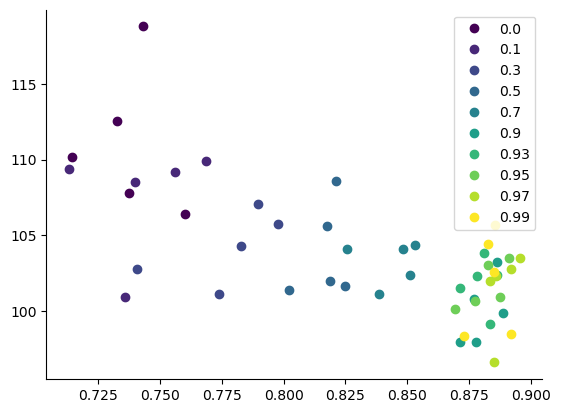

In [38]:
viridis_samples = mpl.colormaps['viridis'].resampled(10)
cycler = plt.cycler(color=viridis_samples.colors)
fig, ax = plt.subplots()
ax.set_prop_cycle(cycler)
for i in alphas:
  df_sub = df_subset[df_subset["model.alpha_scalar"] ==i]
  plt.plot(df_sub["final_scores/coherence/m2_to_m1_cov"], df_sub["val/fid/m2_to_m1_cov"], "o", label=float(i) )
plt.legend()
plt.show()

In [62]:
model_means_jp_cov

,val/fid/m0_to_m0_cov,val/fid/m0_to_m1_cov,val/fid/m0_to_m2_cov,val/fid/m0_to_m3_cov,val/fid/m0_to_m4_cov,val/fid/m1_to_m0_cov,val/fid/m1_to_m1_cov,val/fid/m1_to_m2_cov,val/fid/m1_to_m3_cov,val/fid/m1_to_m4_cov,...,val/fid/m3_to_m0_cov,val/fid/m3_to_m1_cov,val/fid/m3_to_m2_cov,val/fid/m3_to_m3_cov,val/fid/m3_to_m4_cov,val/fid/m4_to_m0_cov,val/fid/m4_to_m1_cov,val/fid/m4_to_m2_cov,val/fid/m4_to_m3_cov,val/fid/m4_to_m4_cov
model.name,,,,,,,,,,,,,,,,,,,,,
0.0,38.264849,184.088486,219.605457,257.072745,303.438470,376.993005,22.649876,164.757053,196.167581,275.789578,...,377.060199,113.443214,167.435223,81.633318,274.365643,380.585522,170.279865,209.213318,243.726828,46.464391
0.1,36.620257,148.126297,194.636951,228.416519,298.900528,355.713306,22.198264,160.777798,194.501752,275.210837,...,355.922406,109.345906,163.523407,79.784515,275.683380,363.209546,160.827118,204.017847,234.944571,46.278059
0.3,37.382989,110.063528,168.809143,203.479730,243.166589,358.347772,22.781501,161.001154,195.619440,240.392374,...,357.993542,105.712685,163.072778,80.004936,240.289471,366.969250,140.971085,193.422238,230.262100,46.471352
0.5,37.274879,102.503038,161.370026,188.064563,210.621173,377.105566,22.109821,161.145590,192.016711,219.287674,...,376.089124,104.425378,163.452393,79.220244,218.350201,387.612701,116.323141,177.765488,210.442221,46.981439
0.7,37.366910,102.182623,163.586417,178.441666,203.791251,363.127216,22.862006,164.675952,186.319019,215.614716,...,364.223840,103.457091,167.081601,78.629820,216.409451,372.885608,106.919009,171.889221,196.869794,47.009303
0.9,35.055304,100.076250,163.224649,175.395395,201.042789,362.754999,22.467968,164.598199,183.086346,209.403751,...,361.344293,99.387192,166.276251,81.125826,208.405310,365.307410,99.894426,167.460971,189.828555,47.898326
0.93,35.944978,101.406404,163.970224,176.949899,201.586642,358.009973,23.083607,165.003824,187.063519,209.072696,...,358.450323,100.738094,166.296149,79.207646,208.199817,361.138416,101.201636,167.788928,193.987448,47.928125
0.95,36.085735,101.901894,161.648322,174.763120,206.602209,354.400677,22.461991,163.444424,183.074771,216.198981,...,353.318555,100.486139,164.599832,79.879742,214.599341,356.635413,100.981578,165.888925,187.336792,47.705721
0.97,35.478082,102.097249,164.529504,172.885968,203.385580,348.455444,22.945365,165.924597,182.406573,212.996634,...,347.641907,100.423239,167.069577,79.530206,210.963437,349.502802,101.171222,168.217490,186.573486,47.832654


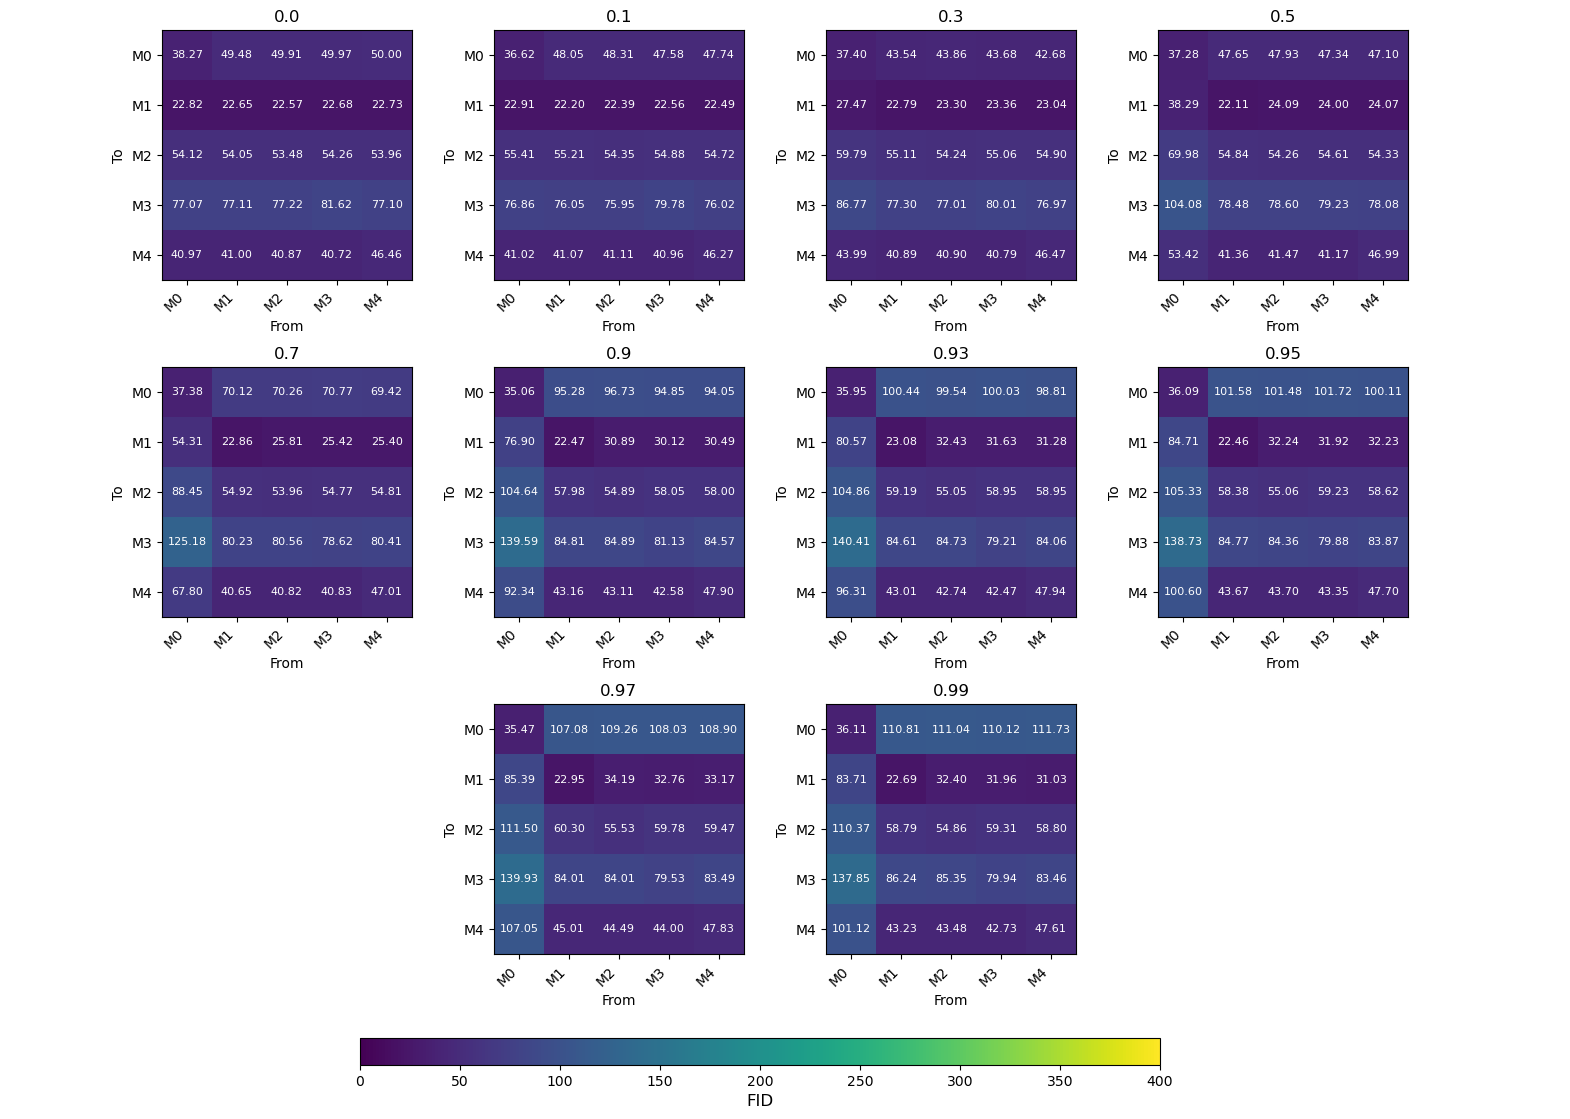

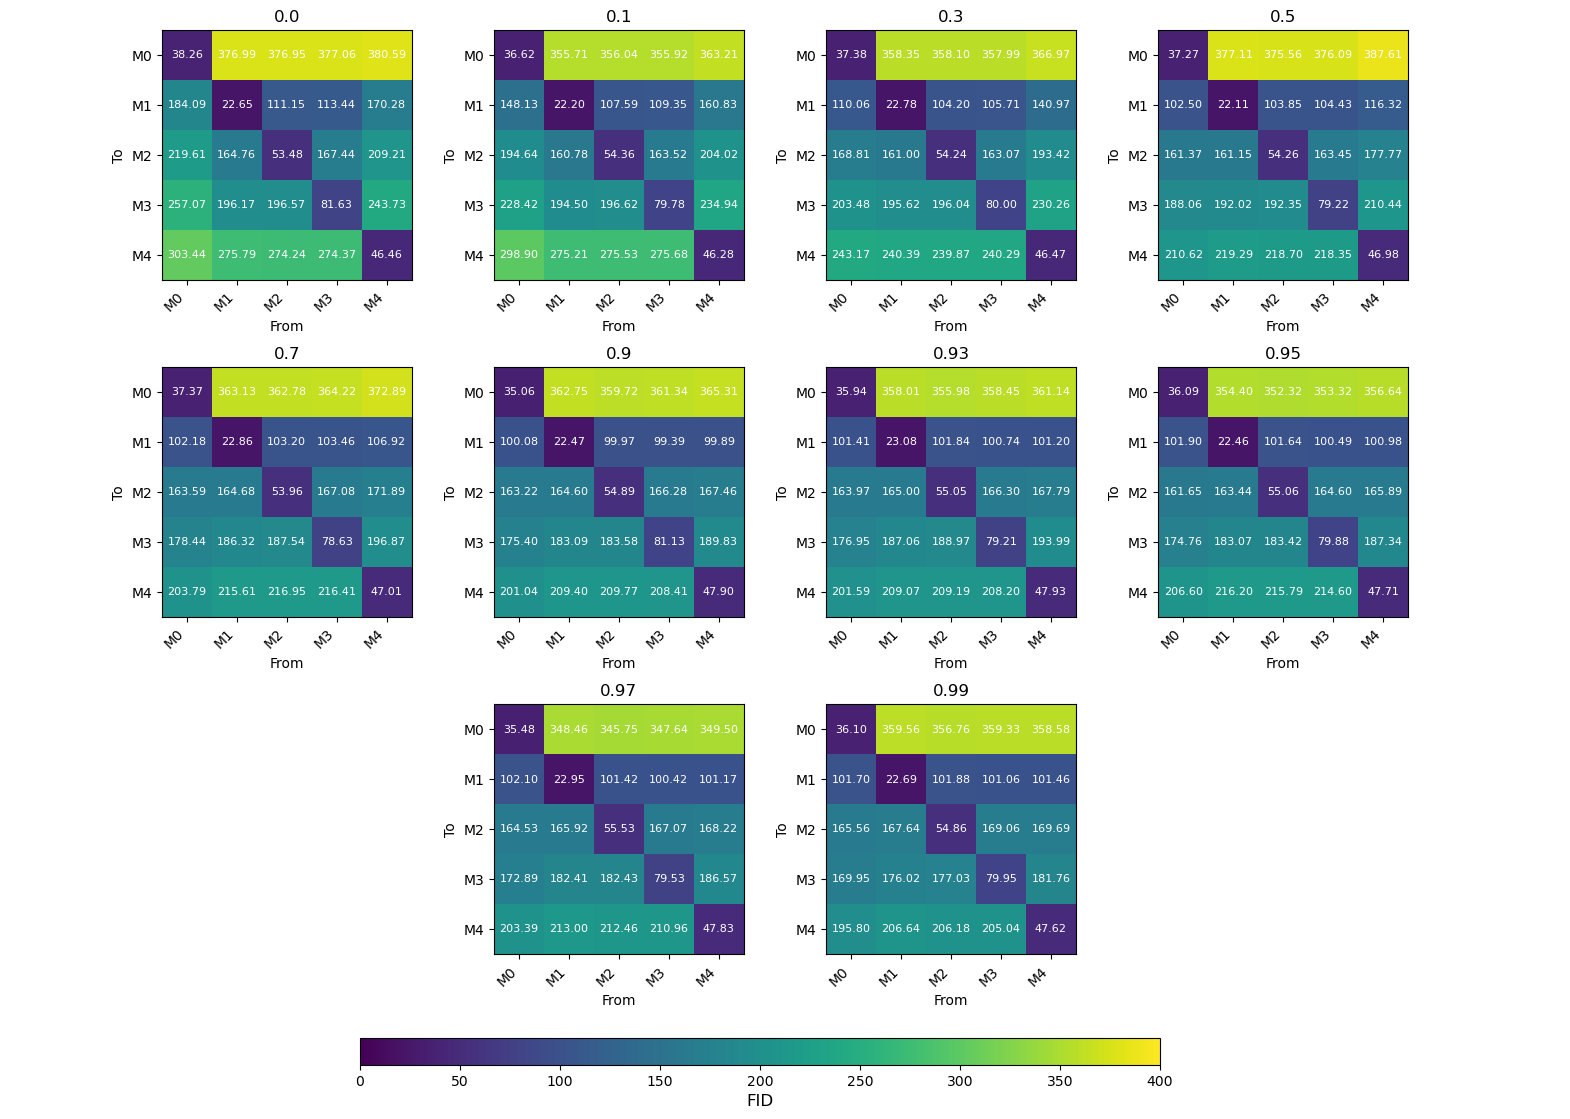

In [39]:
matrices_jp = {name: extract_matrix(row) for name, row in model_means_jp.iterrows()}
matrices_jp_cov = {name: extract_matrix(row, True) for name, row in model_means_jp_cov.iterrows()}
produce_alpha_plots(matrices_jp, "../results_figures/PM_alpha_heatmaps_fid.png", v_max=400, overall_title="FID")
produce_alpha_plots(matrices_jp_cov, "../results_figures/PM_alpha_heatmaps_fid_cov.png",v_max=400, overall_title="FID")

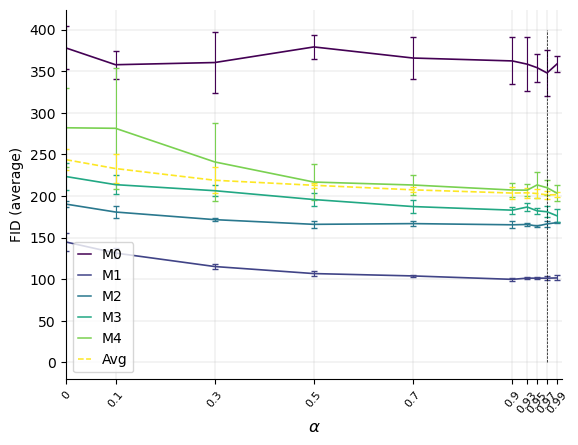

In [40]:
for i, view in enumerate(views):
  cols = ["val/fid/" + col for col in indiv_results[2 * i + 1]]
  average_name = view + "_average"
  best_name = view + "_best"
  model_means_jp_cov[average_name] = model_means_jp_cov[cols].mean(axis=1)
  model_means_jp_cov[best_name] = model_means_jp_cov[cols].max(axis=1)

model_means_jp_cov['average_overall'] = model_means_jp_cov[[view + "_average" for view in views]].mean(axis=1)
model_means_jp_cov['best_overall'] = model_means_jp_cov[[view + "_best" for view in views]].mean(axis=1)
model_means_jp_cov['average_fid'] = model_means_jp_cov[["val/fid/" + view + "_to_" + view + "_cov" for view in views]].mean(axis=1)

cols = ([view + "_average" for view in views])
cols.append('average_overall')
alpha_averages = model_means_jp_cov[cols]
# best
cols = ([view + "_best" for view in views])
cols.append('best_overall')
alpha_best = model_means_jp_cov[cols]
# view-to-view
cols = (["val/fid/" + view + "_to_" + view + "_cov" for view in views])
cols.append('average_fid')
view_to_view_averages = model_means_jp_cov[cols]

legend_names = ["M" + str(i) for i in range(5)]
alpha_values = [float(i) for i in alpha_averages.index]
legend_names.append('Avg')

# Compute per-alpha standard deviation across runs for each plotted metric.
per_run_averages = pd.DataFrame(index=df_subset.index)
per_run_best = pd.DataFrame(index=df_subset.index)
per_run_view_to_view = pd.DataFrame(index=df_subset.index)
for i, view in enumerate(views):
  view_cols = ["val/fid/" + col for col in indiv_results[2 * i + 1]]
  per_run_averages[view + "_average"] = df_subset[view_cols].mean(axis=1)
  per_run_best[view + "_best"] = df_subset[view_cols].max(axis=1)
  diag_col = "val/fid/" + view + "_to_" + view + "_cov"
  per_run_view_to_view[diag_col] = df_subset[diag_col]

per_run_averages['average_overall'] = per_run_averages[[view + "_average" for view in views]].mean(axis=1)
per_run_best['best_overall'] = per_run_best[[view + "_best" for view in views]].mean(axis=1)
per_run_view_to_view['average_fid'] = per_run_view_to_view[["val/fid/" + view + "_to_" + view + "_cov" for view in views]].mean(axis=1)

alpha_errors = per_run_averages.groupby(df_subset['model.name'], observed=False)[alpha_averages.columns].std().reindex(alpha_averages.index).fillna(0.0)
alpha_best_errors = per_run_best.groupby(df_subset['model.name'], observed=False)[alpha_best.columns].std().reindex(alpha_best.index).fillna(0.0)
view_to_view_errors = per_run_view_to_view.groupby(df_subset['model.name'], observed=False)[view_to_view_averages.columns].std().reindex(view_to_view_averages.index).fillna(0.0)

viridis_samples = mpl.colormaps['viridis'].resampled(6)
line_styles = ['-', '-', '-', '-', '-', '--']
cycler = plt.cycler(linestyle=line_styles, color=viridis_samples.colors)
fig, ax = plt.subplots()
ax.set_prop_cycle(cycler)

for col in alpha_averages.columns:
  ax.errorbar(
    alpha_values,
    alpha_averages[col].to_numpy(),
    yerr=alpha_errors[col].to_numpy(),
    capsize=2,
    elinewidth=0.8,
    linewidth=1.2)

ax.set_xlabel(r'$\alpha$', fontsize = 12)
# ax.set_ylim(0, 1.05)
ax.set_xlim(0, 1)
# ax.set_yticks(np.arange(0, 1.1, 0.2))
ax.set_xticks(alpha_values, labels=[f"{a:g}" for a in alpha_values],rotation=50, fontsize=8)
ax.set_ylabel(r'FID (average)')
legend_handles = [
  mpl.lines.Line2D([0], [0], linestyle=ls, color=c, linewidth=1.1)
  for ls, c in zip(line_styles, viridis_samples.colors)
]
ax.legend(legend_handles, legend_names, loc='best', handlelength=0.9)
ax.vlines(
  alpha_values[np.argmin(alpha_averages['average_overall'])],
  0,400,
  linestyles='dashed', 
  linewidth=0.5,
  colors='k')
ax.grid(linewidth=0.2)
plt.savefig('../results_figures/PM_average_impute_fid.png')
plt.show()

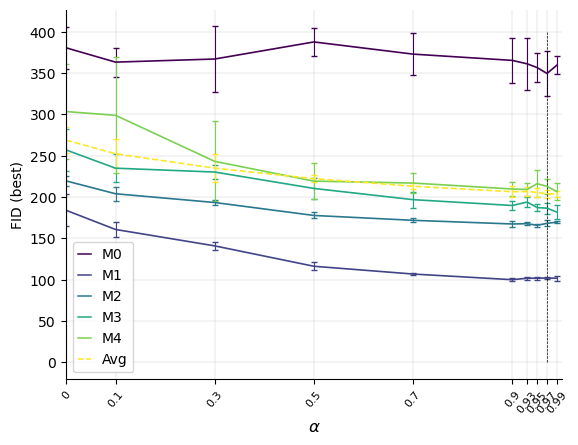

In [41]:
fig, ax = plt.subplots()
ax.set_prop_cycle(cycler)
for col in alpha_best.columns:
  ax.errorbar(
    alpha_values,
    alpha_best[col].to_numpy(),
    yerr=alpha_best_errors[col].to_numpy(),
    capsize=2,
    elinewidth=0.8,
    linewidth=1.2)
ax.set_xlabel(r'$\alpha$', fontsize = 12)
ax.set_ylabel(r'FID (best)')
legend_handles = [
  mpl.lines.Line2D([0], [0], linestyle=ls, color=c, linewidth=1.1)
  for ls, c in zip(line_styles, viridis_samples.colors)
]
ax.legend(legend_handles, legend_names, loc='best', handlelength=0.9)
# ax.set_ylim(0, 1.05)
ax.set_xlim(0, 1)
# ax.set_yticks(np.arange(0, 1.1, 0.2))
ax.set_xticks(alpha_values, labels=[f"{a:g}" for a in alpha_values],rotation=50, fontsize=8)
ax.vlines(
  alpha_values[np.argmin(alpha_best['best_overall'])], 0, 400,
  linestyles='dashed', 
  linewidth=0.5,
  colors='k')
ax.grid(linewidth=0.2)
plt.savefig('../results_figures/PM_best_impute_fid.png')
plt.show()

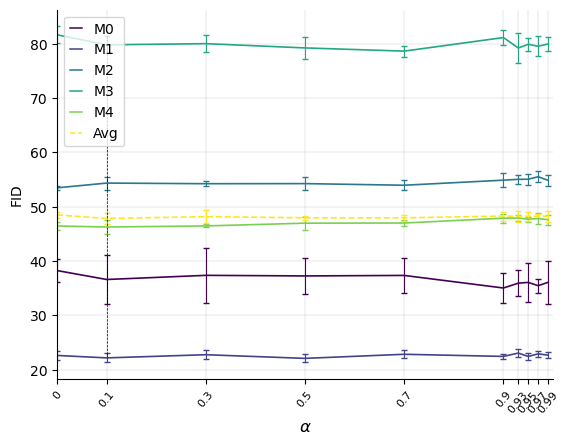

In [42]:
fig, ax = plt.subplots()
ax.set_prop_cycle(cycler)
for col in view_to_view_averages.columns:
  ax.errorbar(
    alpha_values,
    view_to_view_averages[col].to_numpy(),
    yerr=view_to_view_errors[col].to_numpy(),
    capsize=2,
    elinewidth=0.8,
    linewidth=1.2)
ax.set_xlabel(r'$\alpha$', fontsize = 12)
ax.set_xlim(0, 1)
ax.set_xticks(alpha_values, labels=[f"{a:g}" for a in alpha_values],rotation=50, fontsize=8)
ax.set_ylabel(r'FID')
legend_handles = [
  mpl.lines.Line2D([0], [0], linestyle=ls, color=c, linewidth=1.1)
  for ls, c in zip(line_styles, viridis_samples.colors)
]
ax.legend(legend_handles, legend_names, loc='best', handlelength=0.9)
ax.vlines(
  alpha_values[np.argmin(model_means_jp_cov['average_fid'])],
  np.min(view_to_view_averages), np.max(view_to_view_averages), 
  linestyles='dashed', 
  linewidth=0.5,
  colors='k')
ax.grid(linewidth=0.2)
plt.savefig('../results_figures/PM_view_to_view_fid_alpha.png')
plt.show()

### coherence

In [43]:
metric_cols = [c for c in df.columns if "final_scores/coherence/m" in c]
metric_cols_cov = [c for c in metric_cols if "cov" in c]
metric_cols = [c for c in metric_cols if "cov" not in c]
model_means_jp = df_subset.groupby("model.name")[metric_cols].mean()
model_means_jp_cov = df_subset.groupby("model.name")[metric_cols_cov].mean()
matrices_jp = {name: extract_matrix(row) for name, row in model_means_jp.iterrows()}
matrices_jp_cov = {name: extract_matrix(row, True) for name, row in model_means_jp_cov.iterrows()}

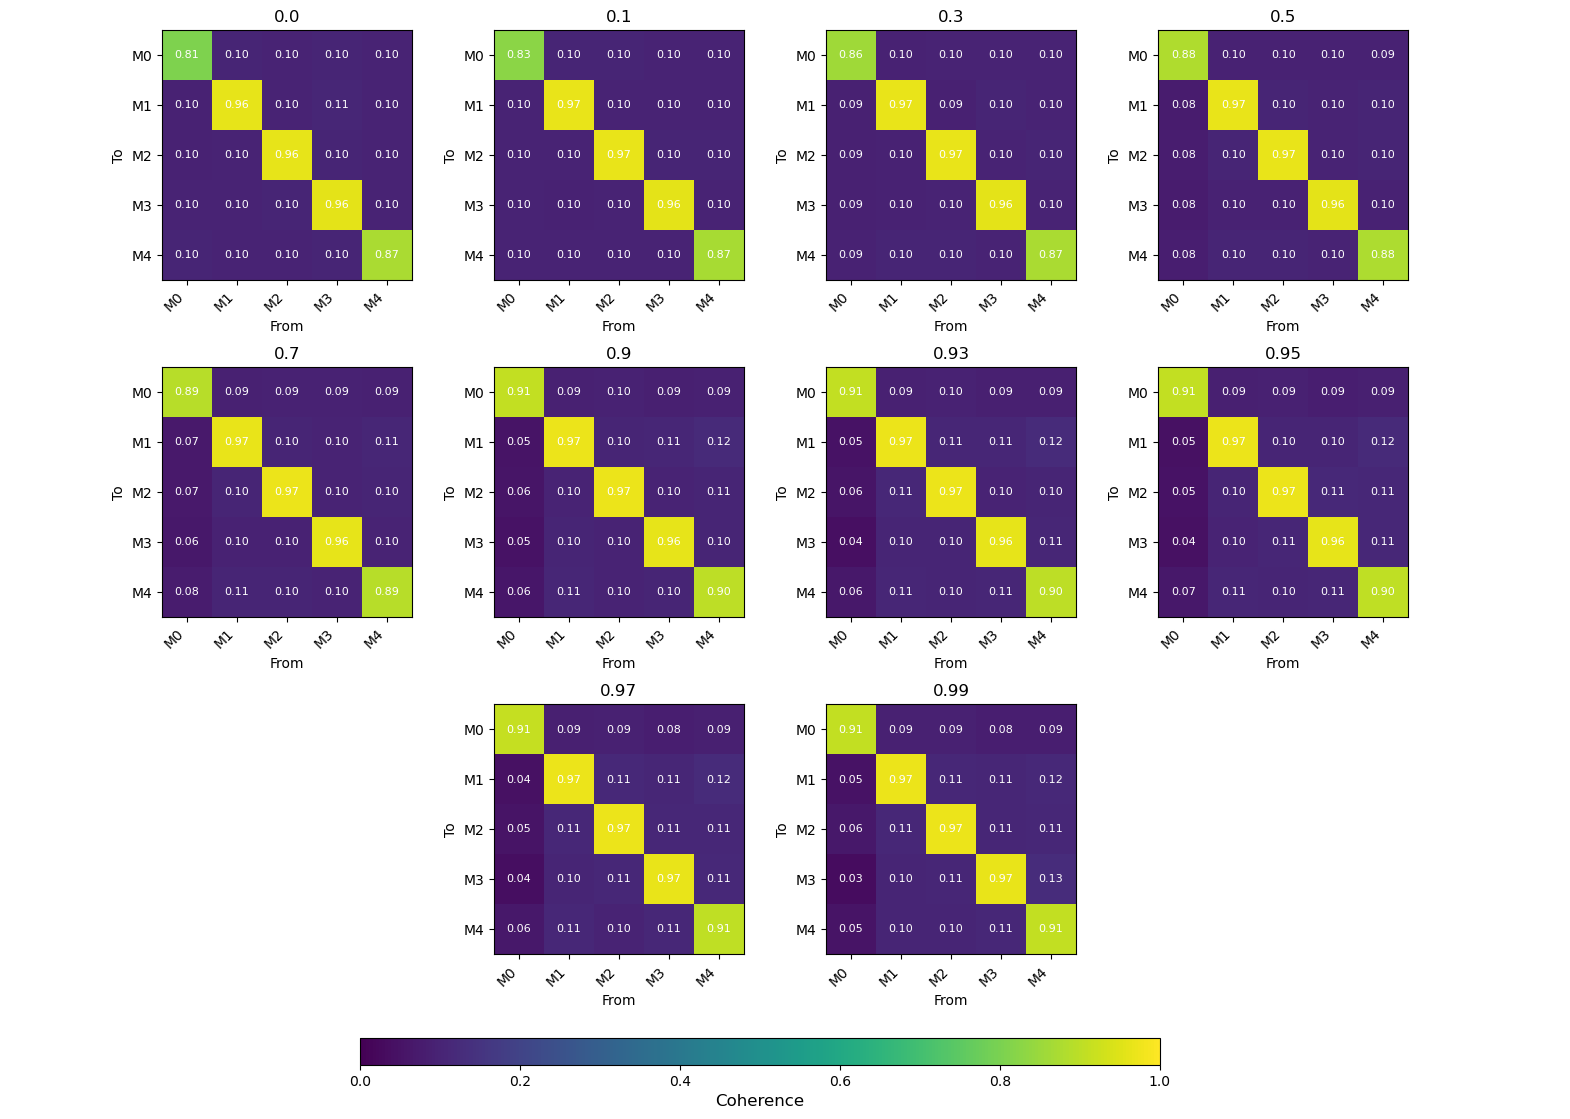

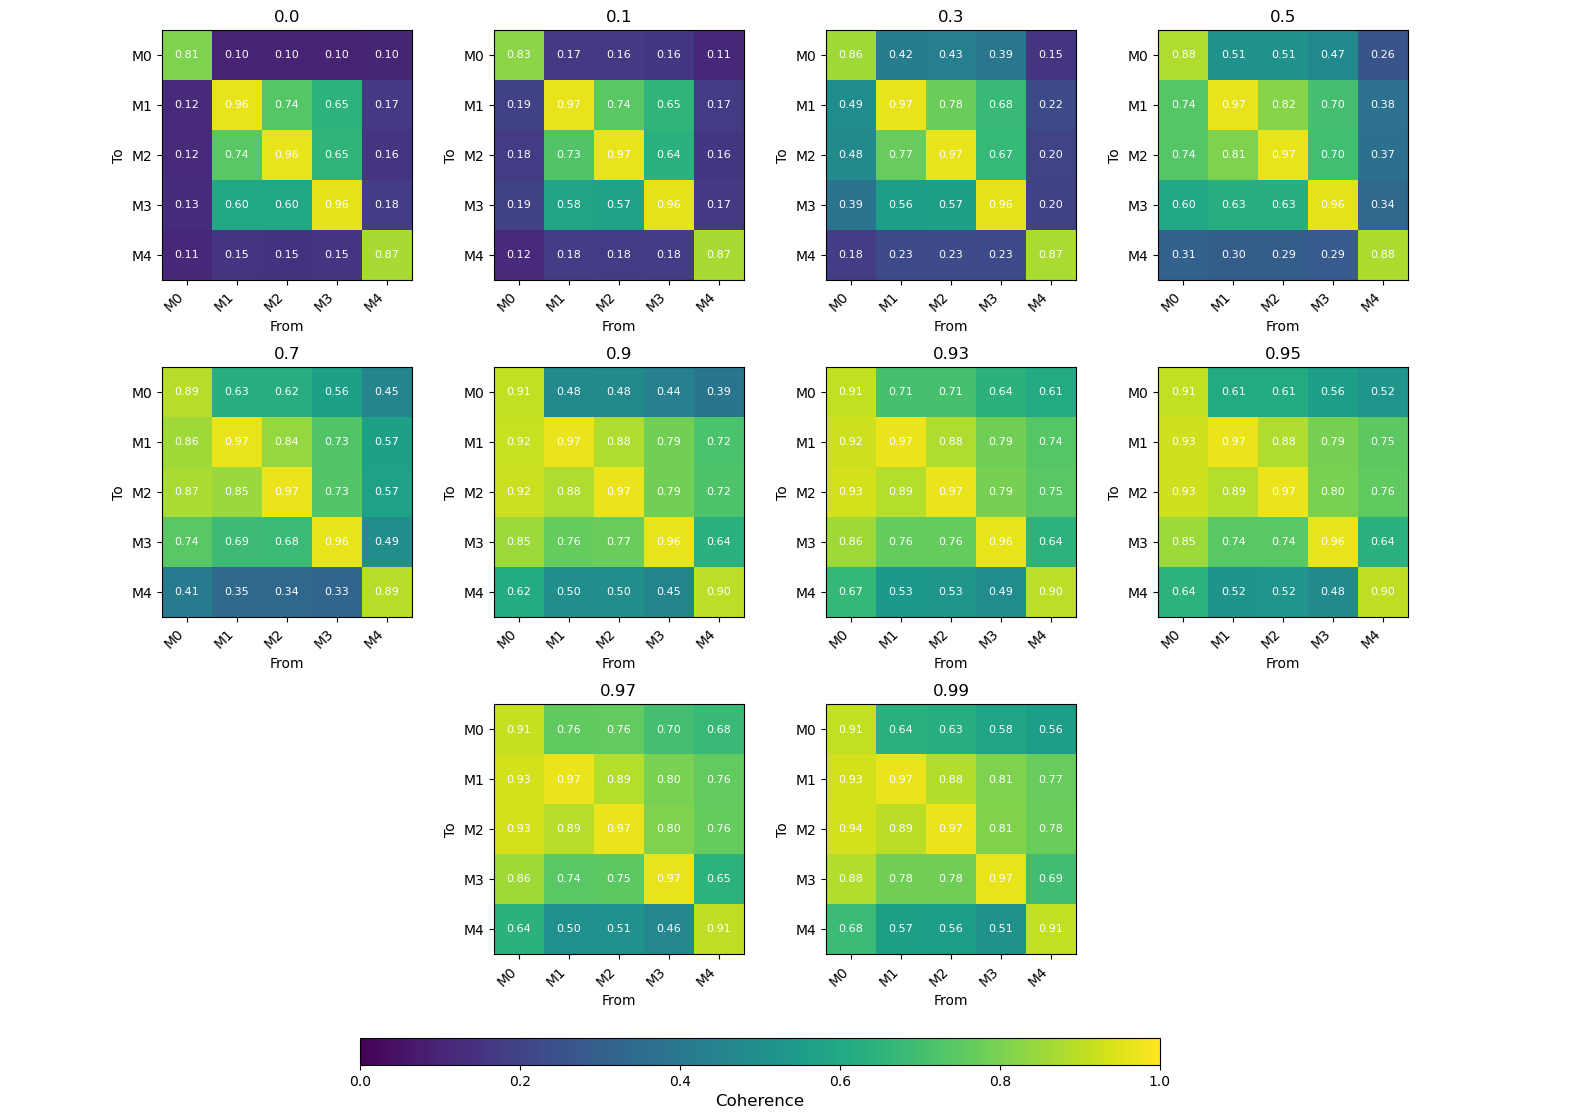

In [44]:
produce_alpha_plots(matrices_jp, "../results_figures/PM_alpha_heatmaps.png")
produce_alpha_plots(matrices_jp_cov, "../results_figures/PM_alpha_heatmaps_cov.png")

In [45]:
for i, view in enumerate(views):
  cols = ["final_scores/coherence/" + col for col in indiv_results[2 * i + 1]]
  average_name = view + "_average"
  best_name = view + "_best"
  model_means_jp_cov[average_name] = model_means_jp_cov[cols].mean(axis=1)
  model_means_jp_cov[best_name] = model_means_jp_cov[cols].max(axis=1)

model_means_jp_cov['average_overall'] = model_means_jp_cov[[view + "_average" for view in views]].mean(axis=1)
model_means_jp_cov['best_overall'] = model_means_jp_cov[[view + "_best" for view in views]].mean(axis=1)
model_means_jp_cov['average_coherence'] = model_means_jp_cov[["final_scores/coherence/" + view + "_to_" + view + "_cov" for view in views]].mean(axis=1)

cols = ([view + "_average" for view in views])
cols.append('average_overall')
alpha_averages = model_means_jp_cov[cols]
# best
cols = ([view + "_best" for view in views])
cols.append('best_overall')
alpha_best = model_means_jp_cov[cols]
# view-to-view
cols = (["final_scores/coherence/" + view + "_to_" + view + "_cov" for view in views])
cols.append('average_coherence')
view_to_view_averages = model_means_jp_cov[cols]

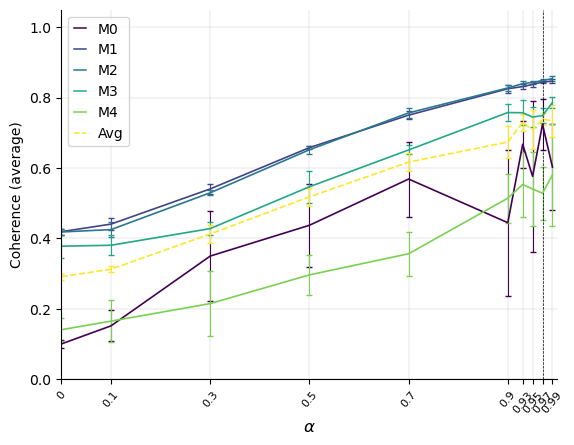

In [46]:
legend_names = ["M" + str(i) for i in range(5)]
alpha_values = [float(i) for i in alpha_averages.index]
legend_names.append('Avg')

# Compute per-alpha standard deviation across runs for each plotted metric.
per_run_averages = pd.DataFrame(index=df_subset.index)
per_run_best = pd.DataFrame(index=df_subset.index)
per_run_view_to_view = pd.DataFrame(index=df_subset.index)
for i, view in enumerate(views):
  view_cols = ["final_scores/coherence/" + col for col in indiv_results[2 * i + 1]]
  per_run_averages[view + "_average"] = df_subset[view_cols].mean(axis=1)
  per_run_best[view + "_best"] = df_subset[view_cols].max(axis=1)
  diag_col = "final_scores/coherence/" + view + "_to_" + view + "_cov"
  per_run_view_to_view[diag_col] = df_subset[diag_col]

per_run_averages['average_overall'] = per_run_averages[[view + "_average" for view in views]].mean(axis=1)
per_run_best['best_overall'] = per_run_best[[view + "_best" for view in views]].mean(axis=1)
per_run_view_to_view['average_coherence'] = per_run_view_to_view[["final_scores/coherence/" + view + "_to_" + view + "_cov" for view in views]].mean(axis=1)

alpha_errors = per_run_averages.groupby(df_subset['model.name'], observed=False)[alpha_averages.columns].std().reindex(alpha_averages.index).fillna(0.0)
alpha_best_errors = per_run_best.groupby(df_subset['model.name'], observed=False)[alpha_best.columns].std().reindex(alpha_best.index).fillna(0.0)
view_to_view_errors = per_run_view_to_view.groupby(df_subset['model.name'], observed=False)[view_to_view_averages.columns].std().reindex(view_to_view_averages.index).fillna(0.0)

viridis_samples = mpl.colormaps['viridis'].resampled(6)
line_styles = ['-', '-', '-', '-', '-', '--']
cycler = plt.cycler(linestyle=line_styles, color=viridis_samples.colors)
fig, ax = plt.subplots()
ax.set_prop_cycle(cycler)

for col in alpha_averages.columns:
  ax.errorbar(
    alpha_values,
    alpha_averages[col].to_numpy(),
    yerr=alpha_errors[col].to_numpy(),
    capsize=2,
    elinewidth=0.8,
    linewidth=1.2)

ax.set_xlabel(r'$\alpha$', fontsize = 12)
ax.set_ylim(0, 1.05)
ax.set_xlim(0, 1)
ax.set_yticks(np.arange(0, 1.1, 0.2))
ax.set_xticks(alpha_values, labels=[f"{a:g}" for a in alpha_values],rotation=50, fontsize=8)
ax.set_ylabel(r'Coherence (average)')
legend_handles = [
  mpl.lines.Line2D([0], [0], linestyle=ls, color=c, linewidth=1.1)
  for ls, c in zip(line_styles, viridis_samples.colors)
]
ax.legend(legend_handles, legend_names, loc='best', handlelength=0.9)
ax.vlines(
  alpha_values[np.argmax(alpha_averages['average_overall'])],
  0,1.05,
  linestyles='dashed', 
  linewidth=0.5,
  colors='k')
ax.grid(linewidth=0.2)
plt.savefig('../results_figures/PM_average_impute_coherence.png')
plt.show()

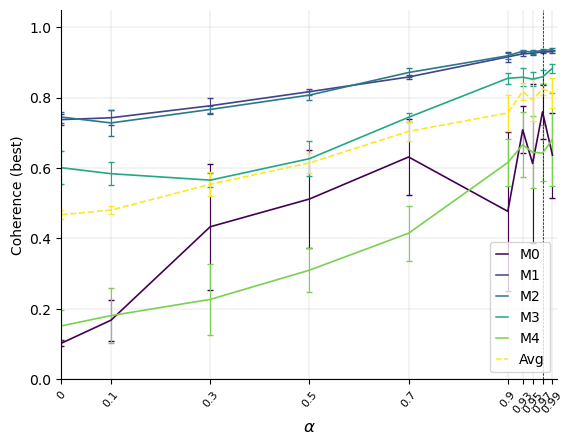

In [47]:
fig, ax = plt.subplots()
ax.set_prop_cycle(cycler)
for col in alpha_best.columns:
  ax.errorbar(
    alpha_values,
    alpha_best[col].to_numpy(),
  
    yerr=alpha_best_errors[col].to_numpy(),
    capsize=2,
    elinewidth=0.8,
    linewidth=1.2)
ax.set_xlabel(r'$\alpha$', fontsize = 12)
ax.set_ylabel(r'Coherence (best)')
legend_handles = [
  mpl.lines.Line2D([0], [0], linestyle=ls, color=c, linewidth=1.1)
  for ls, c in zip(line_styles, viridis_samples.colors)
]
ax.legend(legend_handles, legend_names, loc='best', handlelength=0.9)
ax.set_ylim(0, 1.05)
ax.set_xlim(0, 1)
ax.set_yticks(np.arange(0, 1.1, 0.2))
ax.set_xticks(alpha_values, labels=[f"{a:g}" for a in alpha_values],rotation=50, fontsize=8)
ax.vlines(
  alpha_values[np.argmax(alpha_best['best_overall'])], 0, 1.05,
  linestyles='dashed', 
  linewidth=0.5,
  colors='k')
ax.grid(linewidth=0.2)
plt.savefig('../results_figures/PM_best_impute_coherence.png')
plt.show()

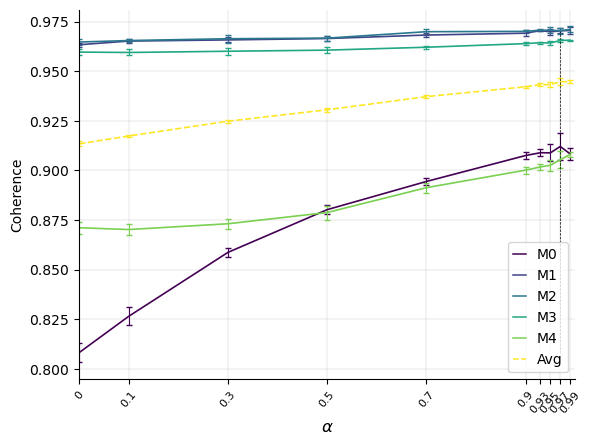

In [48]:
fig, ax = plt.subplots()
ax.set_prop_cycle(cycler)
for col in view_to_view_averages.columns:
  ax.errorbar(
    alpha_values,
    view_to_view_averages[col].to_numpy(),
    yerr=view_to_view_errors[col].to_numpy(),
    capsize=2,
    elinewidth=0.8,
    linewidth=1.2)
ax.set_xlabel(r'$\alpha$', fontsize = 12)
ax.set_xlim(0, 1)
ax.set_xticks(alpha_values, labels=[f"{a:g}" for a in alpha_values],rotation=50, fontsize=8)
ax.set_ylabel(r'Coherence')
legend_handles = [
  mpl.lines.Line2D([0], [0], linestyle=ls, color=c, linewidth=1.1)
  for ls, c in zip(line_styles, viridis_samples.colors)
]
ax.legend(legend_handles, legend_names, loc='best', handlelength=0.9)
ax.vlines(
  alpha_values[np.argmax(model_means_jp_cov['average_coherence'])],
  np.min(view_to_view_averages), np.max(view_to_view_averages), 
  linestyles='dashed', 
  linewidth=0.5,
  colors='k')
ax.grid(linewidth=0.2)
plt.savefig('../results_figures/PM_view_to_view_coherence.png')
plt.show()

### Latent representation 

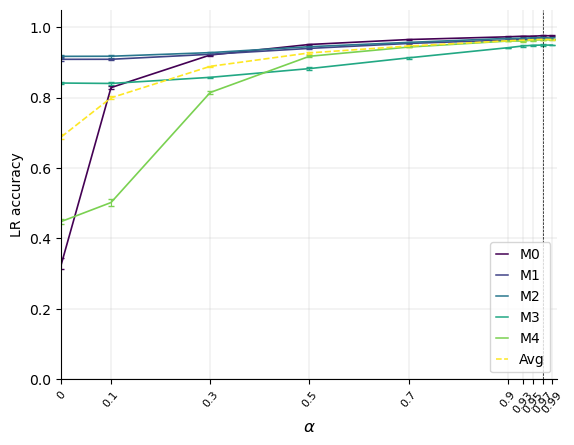

In [49]:
# Alpha plot for unimodal downstream LR scores (m0..m4) with error bars.
unimodal_cols = [f"final_scores/downstream_lr/unimodal/{view}" for view in views]
missing_cols = [c for c in unimodal_cols if c not in df_subset.columns]
if missing_cols:
  raise KeyError(f"Missing columns for unimodal downstream plot: {missing_cols}")

model_means_unimodal = df_subset.groupby("model.name", observed=False)[unimodal_cols].mean()
model_stds_unimodal = df_subset.groupby("model.name", observed=False)[unimodal_cols].std().fillna(0.0)

rename_map = {f"final_scores/downstream_lr/unimodal/m{i}": f"M{i}" for i in range(5)}
model_means_unimodal = model_means_unimodal.rename(columns=rename_map)
model_stds_unimodal = model_stds_unimodal.rename(columns=rename_map)

model_means_unimodal["Avg"] = model_means_unimodal.mean(axis=1)
model_stds_unimodal["Avg"] = model_stds_unimodal.mean(axis=1)

alpha_values_lr = [float(i) for i in model_means_unimodal.index]
legend_names_lr = [f"M{i}" for i in range(5)] + ["Avg"]

viridis_samples = mpl.colormaps["viridis"].resampled(6)
line_styles_lr = ["-", "-", "-", "-", "-", "--"]
cycler_lr = plt.cycler(linestyle=line_styles_lr, color=viridis_samples.colors)

fig, ax = plt.subplots()
ax.set_prop_cycle(cycler_lr)
for col in model_means_unimodal.columns:
  ax.errorbar(
    alpha_values_lr,
    model_means_unimodal[col].to_numpy(),
    yerr=model_stds_unimodal[col].to_numpy(),
    capsize=2,
    elinewidth=0.8,
    linewidth=1.2)

ax.set_xlabel(r"$\alpha$", fontsize=12)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.set_yticks(np.arange(0, 1.1, 0.2))
ax.set_xticks(alpha_values_lr, labels=[f"{a:g}" for a in alpha_values_lr], rotation=50, fontsize=8)
ax.set_ylabel("LR accuracy")
legend_handles_lr = [
  mpl.lines.Line2D([0], [0], linestyle=ls, color=c, linewidth=1.1)
  for ls, c in zip(line_styles_lr, viridis_samples.colors)
]
ax.legend(legend_handles_lr, legend_names_lr, loc="best", handlelength=0.9)
ax.vlines(
  alpha_values_lr[np.argmax(model_means_unimodal["Avg"])],
  0,
  1.05,
  linestyles="dashed",
  linewidth=0.5,
  colors="k")
ax.grid(linewidth=0.2)
plt.savefig("../results_figures/PM_lr_alpha.png")
plt.show()

### Reconstruction loss

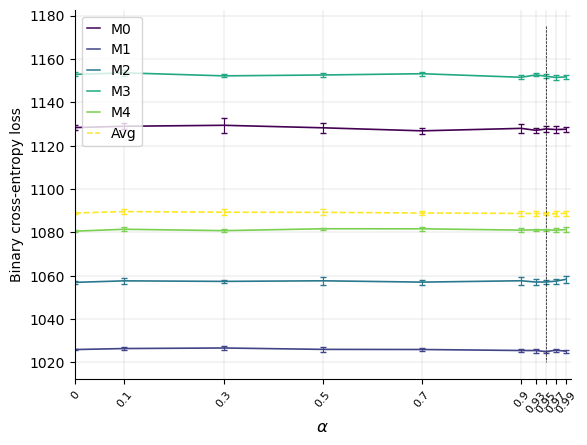

In [50]:
# Alpha plot for unimodal downstream LR scores (m0..m4) with error bars.
unimodal_cols = [f"val/loss/rec_loss_{view}" for view in views]
missing_cols = [c for c in unimodal_cols if c not in df_subset.columns]
if missing_cols:
  raise KeyError(f"Missing columns for unimodal downstream plot: {missing_cols}")

model_means_unimodal = df_subset.groupby("model.name", observed=False)[unimodal_cols].mean()
model_stds_unimodal = df_subset.groupby("model.name", observed=False)[unimodal_cols].std().fillna(0.0)

rename_map = {f"val/loss/rec_loss_{view}": f"M{view}" for view in views}
model_means_unimodal = model_means_unimodal.rename(columns=rename_map)
model_stds_unimodal = model_stds_unimodal.rename(columns=rename_map)

model_means_unimodal["Avg"] = model_means_unimodal.mean(axis=1)
model_stds_unimodal["Avg"] = model_stds_unimodal.mean(axis=1)

alpha_values_lr = [float(i) for i in model_means_unimodal.index]
legend_names_lr = [f"M{i}" for i in range(5)] + ["Avg"]

viridis_samples = mpl.colormaps["viridis"].resampled(6)
line_styles_lr = ["-", "-", "-", "-", "-", "--"]
cycler_lr = plt.cycler(linestyle=line_styles_lr, color=viridis_samples.colors)

fig, ax = plt.subplots()
ax.set_prop_cycle(cycler_lr)
for col in model_means_unimodal.columns:
  ax.errorbar(
    alpha_values_lr,
    -model_means_unimodal[col].to_numpy(),
    yerr=model_stds_unimodal[col].to_numpy(),
    capsize=2,
    elinewidth=0.8,
    linewidth=1.2)

ax.set_xlabel(r"$\alpha$", fontsize=12)
ax.set_xlim(0, 1)
ax.set_xticks(alpha_values_lr, labels=[f"{a:g}" for a in alpha_values_lr], rotation=50, fontsize=8)
ax.set_ylabel("Binary cross-entropy loss")
legend_handles_lr = [
  mpl.lines.Line2D([0], [0], linestyle=ls, color=c, linewidth=1.1)
  for ls, c in zip(line_styles_lr, viridis_samples.colors)
]
ax.legend(legend_handles_lr, legend_names_lr, loc="best", handlelength=0.9)
ax.vlines(
  alpha_values_lr[np.argmax(model_means_unimodal["Avg"])],
  1175,
  1020,
  linestyles="dashed",
  linewidth=0.5,
  colors="k")
ax.grid(linewidth=0.2)
plt.savefig("../results_figures/PM_recon_loss_alpha.png")
plt.show()

In [28]:
model_means_unimodal


,Cond. Rec. Loss,Cond. Rec. Loss (Cov),final_scores/rec_loss
model.name,,,
0.0,5444.498340,5444.499707,5444.654492
0.1,5448.228027,5448.222559,5448.026758
0.3,5446.517383,5446.509277,5446.459277
0.5,5446.304297,5446.300879,5446.200098
0.7,5444.847363,5444.840820,5444.694141
0.9,5443.849512,5443.845215,5443.749512
0.93,5443.489551,5443.485937,5443.448145
0.95,5442.935938,5442.944824,5442.989844
0.97,5443.035645,5443.037012,5443.070703


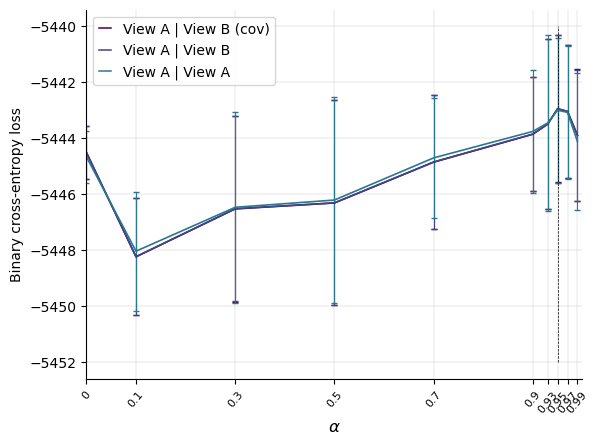

In [51]:
# Alpha plot for unimodal downstream LR scores (m0..m4) with error bars.
unimodal_cols = ["final_scores/cond_rec_loss", f"final_scores/cond_rec_loss_cov", "final_scores/rec_loss"]
missing_cols = [c for c in unimodal_cols if c not in df_subset.columns]
if missing_cols:
  raise KeyError(f"Missing columns for unimodal downstream plot: {missing_cols}")

model_means_unimodal = df_subset.groupby("model.name", observed=False)[unimodal_cols].mean()
model_stds_unimodal = df_subset.groupby("model.name", observed=False)[unimodal_cols].std().fillna(0.0)

rename_map = {f"final_scores/cond_rec_loss": "Cond. Rec. Loss", f"final_scores/cond_rec_loss_cov": "Cond. Rec. Loss (Cov)"  }
model_means_unimodal = model_means_unimodal.rename(columns=rename_map)
model_stds_unimodal = model_stds_unimodal.rename(columns=rename_map)
legend_names_lr = ["View A | View B (cov)", "View A | View B", "View A | View A" ]

viridis_samples = mpl.colormaps["viridis"].resampled(6)
line_styles_lr = ["-", "-", "-", "-", "-", "--"]
cycler_lr = plt.cycler(linestyle=line_styles_lr, color=viridis_samples.colors)
fig, ax = plt.subplots()
ax.set_prop_cycle(cycler_lr)
for col in model_means_unimodal.columns:
  ax.errorbar(
    alpha_values_lr,
    -model_means_unimodal[col].to_numpy(),
    yerr=model_stds_unimodal[col].to_numpy(),
    capsize=2,
    elinewidth=0.8,
    linewidth=1.2)

ax.set_xlabel(r"$\alpha$", fontsize=12)
ax.set_xlim(0, 1)
ax.set_xticks(alpha_values_lr, labels=[f"{a:g}" for a in alpha_values_lr], rotation=50, fontsize=8)
ax.set_ylabel("Binary cross-entropy loss")
legend_handles_lr = [
  mpl.lines.Line2D([0], [0], linestyle=ls, color=c, linewidth=1.1)
  for ls, c in zip(line_styles_lr, viridis_samples.colors)
]
ax.legend(legend_handles_lr, legend_names_lr, loc="best", handlelength=0.9)
ax.vlines(
  alpha_values_lr[np.argmin(model_means_unimodal["Cond. Rec. Loss (Cov)"])],
  -5452,
  -5440,
  linestyles="dashed",
  linewidth=0.5,
  colors="k")
ax.grid(linewidth=0.2)
plt.savefig("../results_figures/PM_recon_loss_alpha_average.png")
plt.show()

# Modality comparison

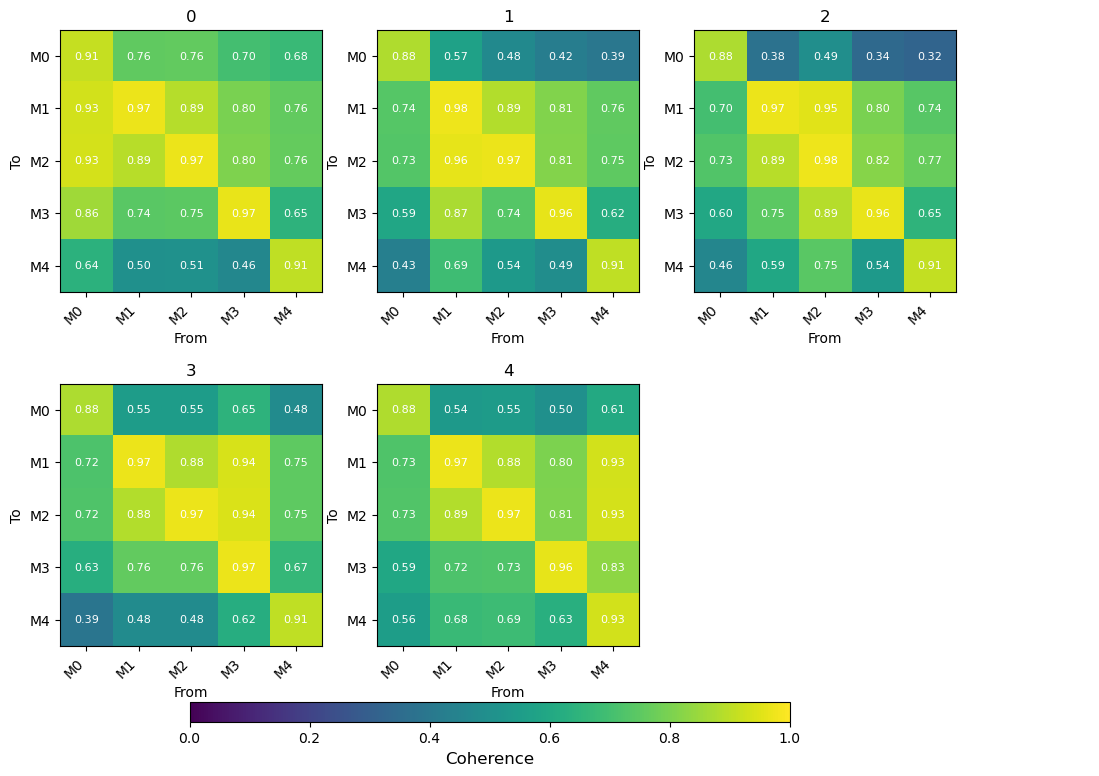

In [ ]:
model_means_jp_mod = df_modality.groupby("dataset.modalities_order")[metric_cols_cov].mean()
matrices_jp_mod = {name: extract_matrix(row, True) for name, row in model_means_jp_mod.iterrows()}
produce_alpha_plots(matrices_jp_mod, "../results_figures/alpha_heatmaps_mod.png", n_rows=2, n_cols=3)

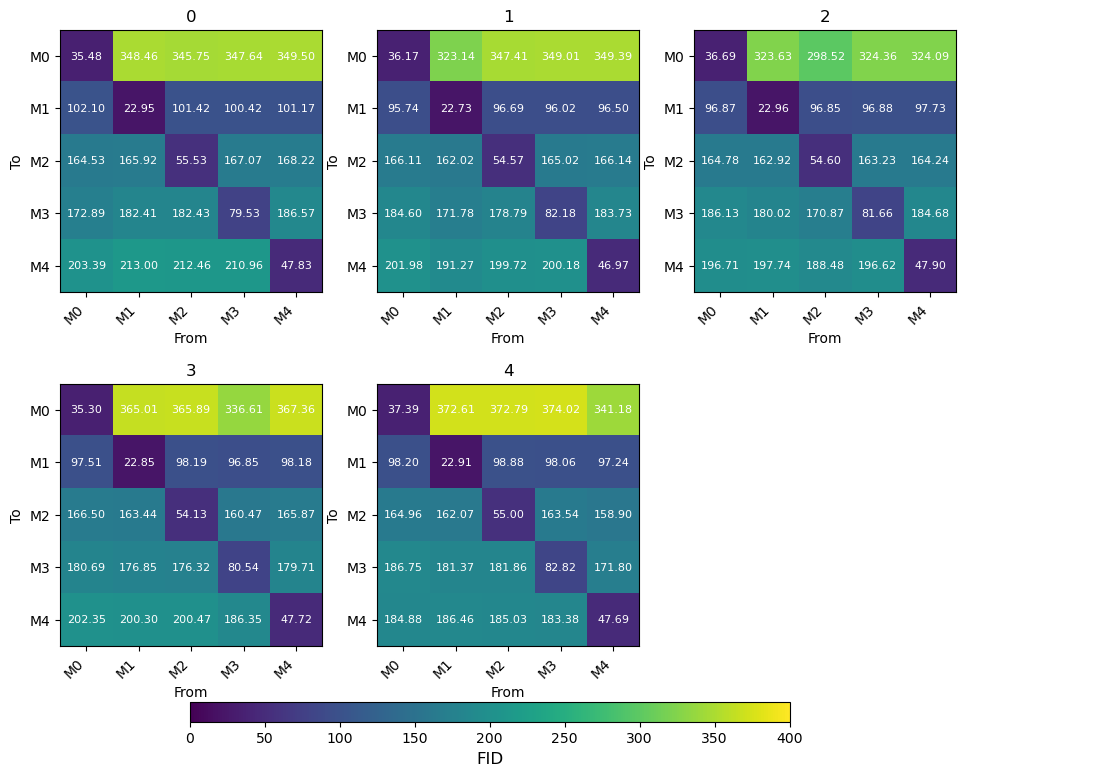

In [231]:
metric_cols_fid = [c for c in df.columns if "val/fid/m" in c]
metric_cols_cov_fid = [c for c in metric_cols_fid if "cov" in c]
metric_cols_fid = [c for c in metric_cols_fid if "cov" not in c]
model_means_jp_mod = df_modality.groupby("dataset.modalities_order")[metric_cols_cov_fid].mean()
matrices_jp_mod = {name: extract_matrix(row, True) for name, row in model_means_jp_mod.iterrows()}
produce_alpha_plots(matrices_jp_mod, "../results_figures/alpha_heatmaps_mod_fid.png", n_rows=2, n_cols=3,v_max=400, overall_title="FID")

In [83]:
indiv_results

[['m1_to_m0', 'm2_to_m0', 'm3_to_m0', 'm4_to_m0'],
 ['m1_to_m0_cov', 'm2_to_m0_cov', 'm3_to_m0_cov', 'm4_to_m0_cov'],
 ['m0_to_m1', 'm2_to_m1', 'm3_to_m1', 'm4_to_m1'],
 ['m0_to_m1_cov', 'm2_to_m1_cov', 'm3_to_m1_cov', 'm4_to_m1_cov'],
 ['m0_to_m2', 'm1_to_m2', 'm3_to_m2', 'm4_to_m2'],
 ['m0_to_m2_cov', 'm1_to_m2_cov', 'm3_to_m2_cov', 'm4_to_m2_cov'],
 ['m0_to_m3', 'm1_to_m3', 'm2_to_m3', 'm4_to_m3'],
 ['m0_to_m3_cov', 'm1_to_m3_cov', 'm2_to_m3_cov', 'm4_to_m3_cov'],
 ['m0_to_m4', 'm1_to_m4', 'm2_to_m4', 'm3_to_m4'],
 ['m0_to_m4_cov', 'm1_to_m4_cov', 'm2_to_m4_cov', 'm3_to_m4_cov'],
 ['m0_to_m0', 'm1_to_m1', 'm2_to_m2', 'm3_to_m3', 'm4_to_m4'],
 ['m0_to_m0_cov',
  'm1_to_m1_cov',
  'm2_to_m2_cov',
  'm3_to_m3_cov',
  'm4_to_m4_cov']]

In [101]:
for i, view in enumerate(views):
  cols = ["final_scores/coherence/" + col for col in indiv_results[2 * i + 1]]
  average_name = view + "_average"
  best_name = view + "_best"
  model_means_jp_mod[average_name] = model_means_jp_mod[cols].mean(axis=1)
  model_means_jp_mod[best_name] = model_means_jp_mod[cols].max(axis=1)

model_means_jp_mod['average_overall'] = model_means_jp_mod[[view + "_average" for view in views]].mean(axis=1)
model_means_jp_mod['best_overall'] = model_means_jp_mod[[view + "_best" for view in views]].mean(axis=1)
model_means_jp_mod['average_coherence'] = model_means_jp_mod[["final_scores/coherence/" + view + "_to_" + view + "_cov" for view in views]].mean(axis=1)

cols = ([view + "_average" for view in views])
cols.append('average_overall')
alpha_averages = model_means_jp_mod[cols]
# best
cols = ([view + "_best" for view in views])
cols.append('best_overall')
alpha_best = model_means_jp_mod[cols]
# view-to-view
cols = (["final_scores/coherence/" + view + "_to_" + view + "_cov" for view in views])
cols.append('average_coherence')
view_to_view_averages = model_means_jp_mod[cols]

KeyError: "None of [Index(['final_scores/coherence/m1_to_m0_cov',\n       'final_scores/coherence/m2_to_m0_cov',\n       'final_scores/coherence/m3_to_m0_cov',\n       'final_scores/coherence/m4_to_m0_cov'],\n      dtype='object')] are in the [columns]"

In [89]:
# create a matrix where entry i j is the best imputed coherence using modality order i and imputing view j, not using view j
best_imputed_coherence = np.zeros((5, 5))
average_imputed_coherence = np.zeros((5, 5))
for i, view_a in enumerate(views):
  for j, view_b in enumerate(views):
    # if view_a != view_b:
      best_imputed_coherence[j, i] = model_means_jp_mod[view_b + "_best"].iloc[i]
      average_imputed_coherence[j, i] = model_means_jp_mod[view_b + "_average"].iloc[i]

['M0', 'M1', 'M2', 'M3', 'M4']

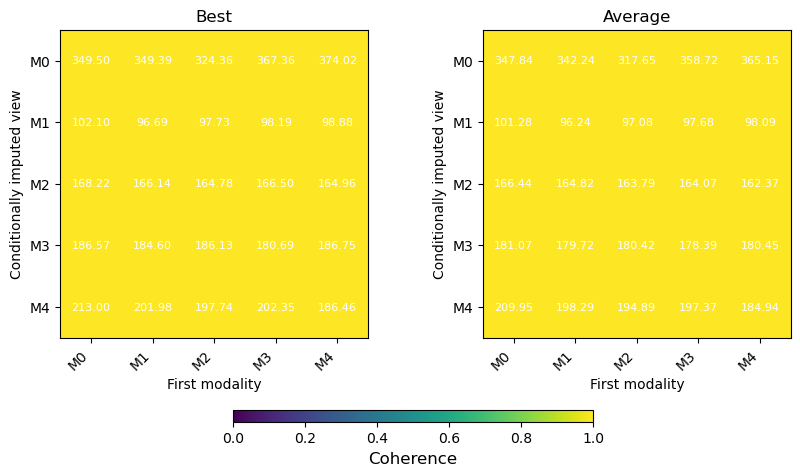

In [98]:
# convert these matrices to be used in the alpha plots function
view_labels = [f"M{i}" for i in range(5)]
best_imputed_coherence_df = pd.DataFrame(best_imputed_coherence, index=view_labels, columns=view_labels)
average_imputed_coherence_df = pd.DataFrame(average_imputed_coherence, index=view_labels, columns=view_labels)
coherence_matrices = {
    "Best": best_imputed_coherence_df,
    "Average": average_imputed_coherence_df,
  
}
produce_alpha_plots(coherence_matrices, "../results_figures/best_average_imputed_fid.png", n_rows=1, n_cols=2)

In [105]:

for i, view in enumerate(views):
  cols = ["val/fid/" + col for col in indiv_results[2 * i + 1]]
  average_name = view + "_average"
  best_name = view + "_best"
  model_means_jp_mod[average_name] = model_means_jp_mod[cols].mean(axis=1)
  model_means_jp_mod[best_name] = model_means_jp_mod[cols].max(axis=1)

model_means_jp_mod['average_overall'] = model_means_jp_mod[[view + "_average" for view in views]].mean(axis=1)
model_means_jp_mod['best_overall'] = model_means_jp_mod[[view + "_best" for view in views]].mean(axis=1)
model_means_jp_mod['average_fid'] = model_means_jp_mod[["val/fid/" + view + "_to_" + view + "_cov" for view in views]].mean(axis=1)

cols = ([view + "_average" for view in views])
cols.append('average_overall')
alpha_averages = model_means_jp_mod[cols]
# best
cols = ([view + "_best" for view in views])
cols.append('best_overall')
alpha_best = model_means_jp_mod[cols]
# view-to-view
cols = (["val/fid/" + view + "_to_" + view + "_cov" for view in views])
cols.append('average_fid')
view_to_view_averages = model_means_jp_mod[cols]

best_imputed_coherence = np.zeros((5, 5))
average_imputed_coherence = np.zeros((5, 5))
for i, view_a in enumerate(views):
  for j, view_b in enumerate(views):
    # if view_a != view_b:
      best_imputed_coherence[j, i] = model_means_jp_mod[view_b + "_best"].iloc[i]
      average_imputed_coherence[j, i] = model_means_jp_mod[view_b + "_average"].iloc[i]

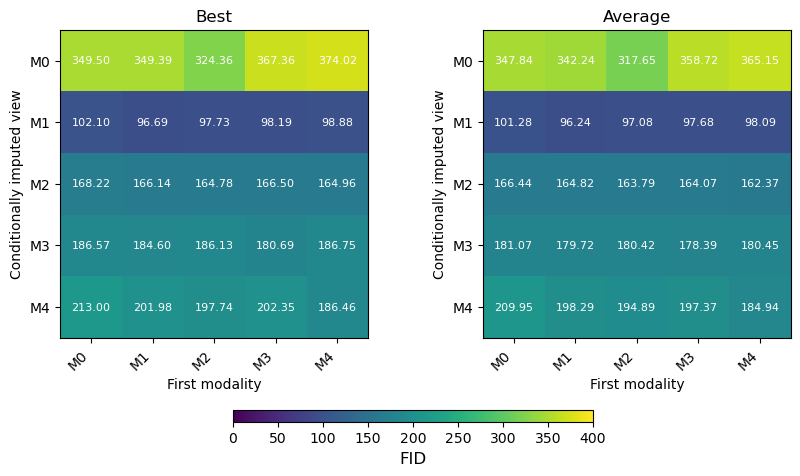

In [114]:
# convert these matrices to be used in the alpha plots function
view_labels = [f"M{i}" for i in range(5)]
best_imputed_coherence_df = pd.DataFrame(best_imputed_coherence, index=view_labels, columns=view_labels)
average_imputed_coherence_df = pd.DataFrame(average_imputed_coherence, index=view_labels, columns=view_labels)
coherence_matrices = {
    "Best": best_imputed_coherence_df,
    "Average": average_imputed_coherence_df,
  
}
produce_alpha_plots(coherence_matrices,
                    "../results_figures/best_average_imputed_fid.png", n_rows=1, n_cols=2, v_max=400, overall_title="FID")

In [239]:
best_imputed_coherence.mean(axis=0)

array([0.82510817, 0.79631811, 0.79428686, 0.78293269, 0.79772436])

In [240]:
average_imputed_coherence.mean(axis=0)

array([0.73888922, 0.66458433, 0.65761118, 0.68105869, 0.71615685])

# Method comparison

In [225]:
labels=['independent', 'AVG', 'MoE', 'MoPoE','MMVM','JP']
df_comparison['model.name'] = pd.Categorical(df_comparison['model.name'], labels, ordered=True)
df_comparison['model.name'] = df_comparison['model.name'].cat.rename_categories({
    'independent': 'independent',
    'AVG': 'AVG',
    'MoE': 'MoE',
    'MoPoE': 'MoPoE',
    'MMVM': 'MMVM',
    'JP': 'JPVAE'
})
df_comparison["model.alpha_scalar"] = df_comparison["model.alpha_scalar"].fillna(0)
df_subset = df_comparison.copy()
model_means = df_subset.groupby("model.name", observed=True)[metric_cols].mean()
model_means_cov = df_subset.groupby("model.name", observed=True)[metric_cols_cov].mean()
matrices = {name: extract_matrix(row) for name, row in model_means.iterrows()}
matrices_cov = {name: extract_matrix(row, True) for name, row in model_means_cov.iterrows()}
matrix_diff = {}
for key in matrices_cov.keys():
  matrix_diff[key] = matrices_cov[key] - matrices[key] 

In [226]:
# final results
matrices_final = {'independent': matrices_cov['independent'], 'AVG': matrices_cov['AVG'], 'MoE': matrices['MoE'], 'MoPoE': matrices['MoPoE'],'MMVM': matrices['MMVM'],'JPVAE': matrices_cov['JPVAE']}

In [205]:
matrices_final

{'independent': from        M0        M1        M2        M3        M4
 to                                                    
 M0    0.808153  0.099119  0.098217  0.101462  0.102424
 M1    0.121975  0.963341  0.737600  0.645994  0.171294
 M2    0.119351  0.744812  0.964704  0.653526  0.155869
 M3    0.131951  0.597095  0.600901  0.959635  0.181811
 M4    0.113722  0.149499  0.147736  0.151583  0.871094,
 'AVG': from        M0        M1        M2        M3        M4
 to                                                    
 M0    0.536659  0.311558  0.296354  0.289083  0.271514
 M1    0.512179  0.767748  0.705950  0.708133  0.629547
 M2    0.504107  0.738582  0.695633  0.695994  0.620553
 M3    0.493870  0.784655  0.735938  0.841166  0.635877
 M4    0.427524  0.682011  0.627063  0.635637  0.440645,
 'MoE': from        M0        M1        M2        M3        M4
 to                                                    
 M0    0.780849  0.846254  0.847376  0.815805  0.828566
 M1    0.867728  

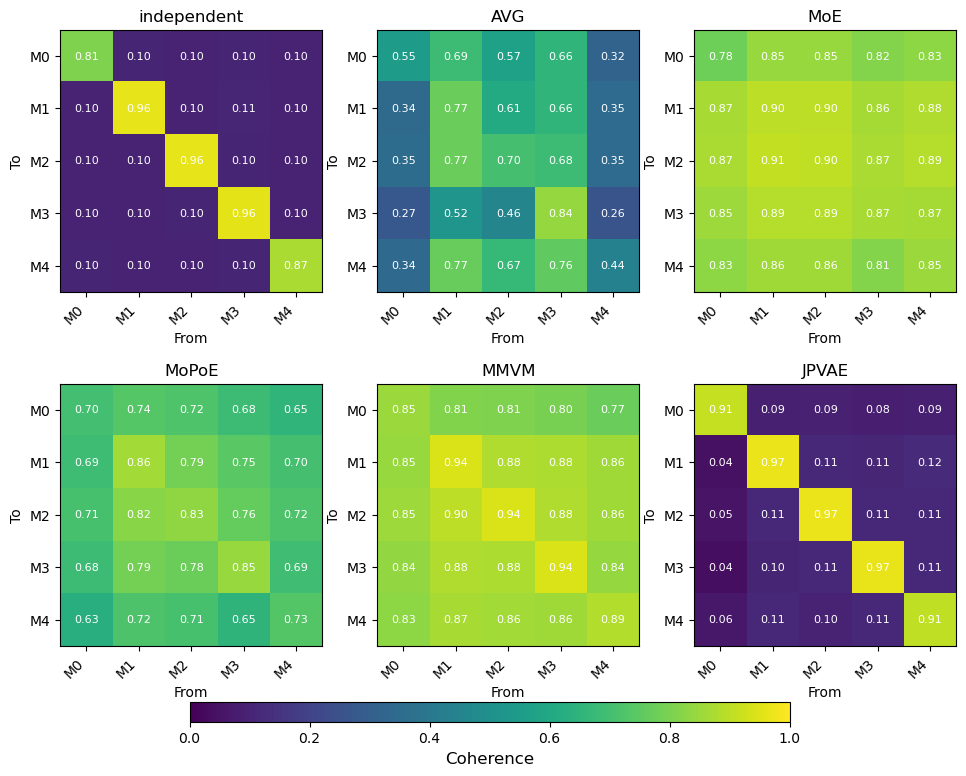

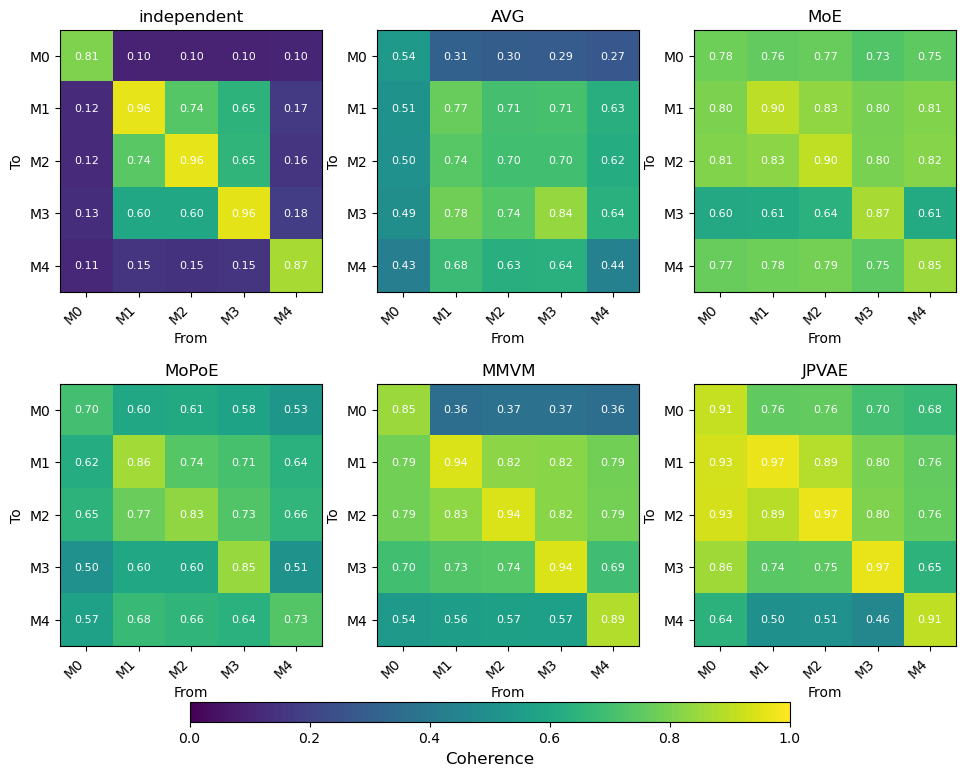

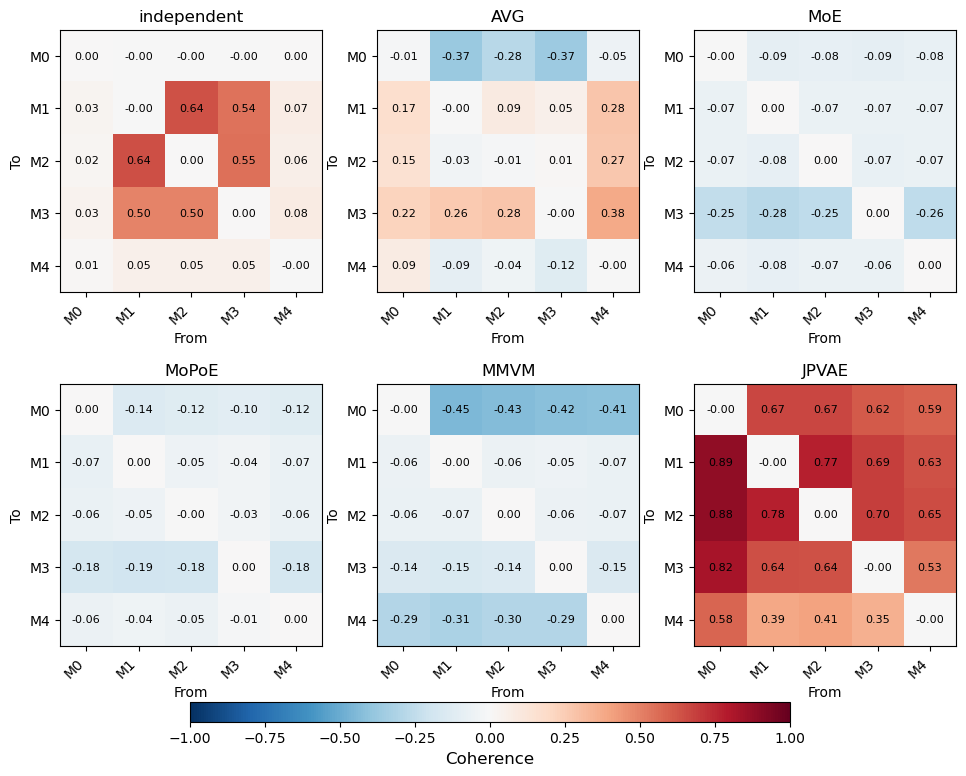

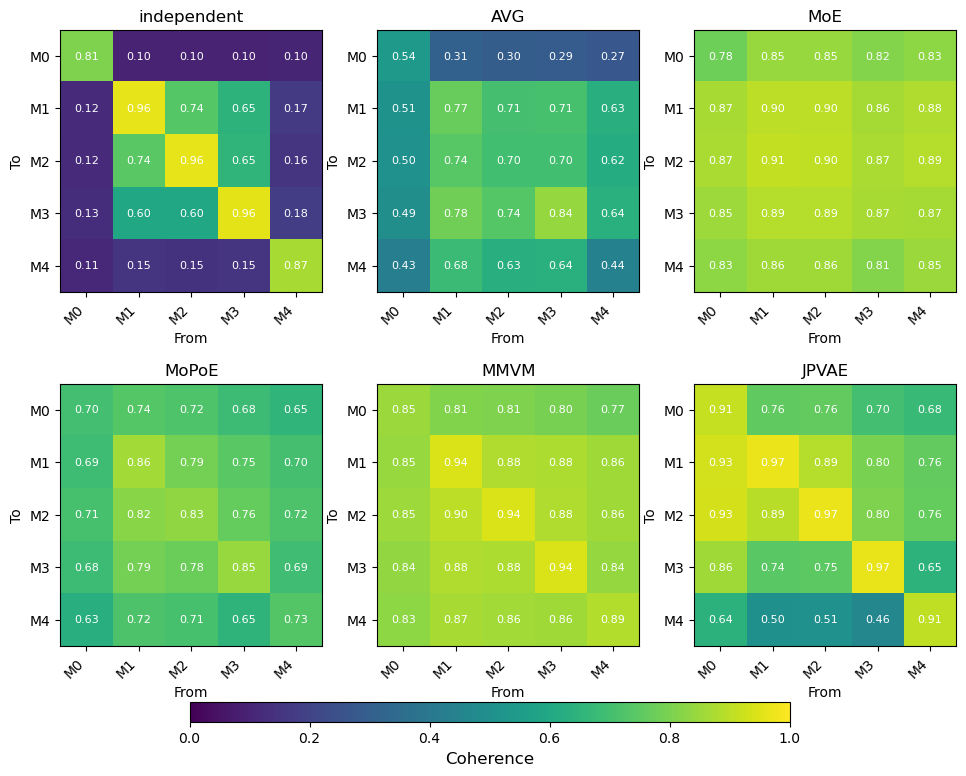

In [191]:
produce_alpha_plots(matrices,  "../results_figures/methods_heatmaps.png", n_rows=2, n_cols=3)
produce_alpha_plots(matrices_cov,  "../results_figures/methods_heatmaps_cov.png", n_rows=2, n_cols=3)
produce_alpha_plots(matrix_diff,  "../results_figures/methods_heatmaps_diff.png",v_min =-1, color_map='RdBu_r', text_color='k', n_rows=2, n_cols=3)
produce_alpha_plots(matrices_final,  "../results_figures/methods_heatmaps_best.png", n_rows=2, n_cols=3)

In [227]:
best_vals = [(np.diag(matrix)).mean() for matrix in matrices_final.values()]

In [228]:
best_vals

[np.float64(0.9133854150772095),
 np.float64(0.656370186805725),
 np.float64(0.860649049282074),
 np.float64(0.7943589711189271),
 np.float64(0.9131810927391053),
 np.float64(0.9447275662422181)]

In [222]:
best_vals = [(np.diag(matrix)).mean() for matrix in matrices_final.values()]
# make dataframe with best_vals
best_vals_df = pd.DataFrame(np.array(best_vals), 
                            index=matrices_final.keys(), columns=[f"M{i}" for i in range(5)])
coh_best_vals = best_vals_df.mean(axis=1)
# round to 3 significant figures
best_vals_df_rounded = best_vals_df.round(3)
# create a latex table from the dataframe
latex_table = best_vals_df_rounded.to_latex(index=True, caption="Best Imputed Coherence for Each Method", label="tab:best_imputed_coherence", float_format="%.3f")
# save to file
with open("../results_figures/best_direct_coherence_table.tex", "w") as f:
    f.write(latex_table)

ValueError: Shape of passed values is (6, 1), indices imply (6, 5)

In [217]:
best_vals = [(matrix - np.diag(np.diag(matrix))).max(axis=1) for matrix in matrices_final.values()]
# make dataframe with best_vals
best_vals_df = pd.DataFrame(np.array(best_vals), 
                            index=matrices_final.keys(), columns=[f"M{i}" for i in range(5)])
coh_best_vals = best_vals_df.mean(axis=1)
# round to 3 significant figures
best_vals_df_rounded = best_vals_df.round(3)
# create a latex table from the dataframe
latex_table = best_vals_df_rounded.to_latex(index=True, caption="Best Imputed Coherence for Each Method", label="tab:best_imputed_coherence", float_format="%.3f")
# save to file
with open("../results_figures/best_imputed_coherence_table.tex", "w") as f:
    f.write(latex_table)

In [236]:
model_means

,val/fid/m0_to_m0,val/fid/m0_to_m1,val/fid/m0_to_m2,val/fid/m0_to_m3,val/fid/m0_to_m4,val/fid/m1_to_m0,val/fid/m1_to_m1,val/fid/m1_to_m2,val/fid/m1_to_m3,val/fid/m1_to_m4,...,val/fid/m3_to_m0,val/fid/m3_to_m1,val/fid/m3_to_m2,val/fid/m3_to_m3,val/fid/m3_to_m4,val/fid/m4_to_m0,val/fid/m4_to_m1,val/fid/m4_to_m2,val/fid/m4_to_m3,val/fid/m4_to_m4
model.name,,,,,,,,,,,,,,,,,,,,,
independent,38.273823,22.821574,54.117068,77.068314,40.965921,49.482207,22.652903,54.046616,77.108998,41.000278,...,49.971129,22.675706,54.256786,81.620688,40.717416,50.004117,22.730172,53.962016,77.104594,46.464207
AVG,146.080673,121.124960,156.985031,139.190140,160.177774,176.823077,125.435187,138.354184,137.332288,145.858496,...,181.949777,117.025768,146.170502,178.383841,145.569473,185.969040,122.231512,157.299423,139.075168,134.739117
MoE,103.316158,154.382092,154.747519,276.269891,236.265170,196.045685,69.629473,162.756076,280.585455,238.052557,...,192.459122,154.612601,157.386057,130.907193,231.504333,193.863455,157.966589,160.019739,277.570178,75.357829
MoPoE,79.617859,142.017538,127.488409,244.469623,180.605884,176.364273,52.906091,133.428616,250.070850,189.796695,...,167.217395,141.937796,126.653433,116.899031,179.877634,168.029193,149.292300,128.487866,243.963425,60.392137
MMVM,50.073325,36.786911,67.280222,101.112206,59.077071,54.929503,35.818478,68.427423,103.926003,61.028001,...,56.801367,36.474998,67.061188,99.768958,58.639607,56.337724,36.905555,67.538568,101.720235,55.543504


In [239]:
metric_cols_fid = [c for c in df.columns if "val/fid/m" in c]
metric_cols_cov_fid = [c for c in metric_cols_fid if "cov" in c]
metric_cols_fid = [c for c in metric_cols_fid if "cov" not in c]
labels=['independent', 'AVG', 'MoE', 'MoPoE','MMVM','JP']
df_comparison['model.name'] = pd.Categorical(df_comparison['model.name'], labels, ordered=True)
df_comparison["model.alpha_scalar"] = df_comparison["model.alpha_scalar"].fillna(0)
df_subset = df_comparison.copy()
model_means = df_subset.groupby("model.name", observed=True)[metric_cols_fid].mean()
model_means_cov = df_subset.groupby("model.name", observed=True)[metric_cols_cov_fid].mean()
matrices = {name: extract_matrix(row) for name, row in model_means.iterrows()}
matrices_cov = {name: extract_matrix(row, True) for name, row in model_means_cov.iterrows()}
matrix_diff = {}
for key in matrices_cov.keys():
  matrix_diff[key] = matrices_cov[key] - matrices[key] 
  
# final results
matrices_final = {'independent': matrices_cov['independent'], 'AVG': matrices_cov['AVG'], 'MoE': matrices['MoE'], 'MoPoE': matrices['MoPoE'],'MMVM': matrices['MMVM'],'JP': matrices_cov['JP']}

In [216]:
df_comparison[[col for col in df_comparison.columns if "val/fid" in col]]

,val/fid/m0_to_m0,val/fid/m0_to_m0_cov,val/fid/m0_to_m1,val/fid/m0_to_m1_cov,val/fid/m0_to_m2,val/fid/m0_to_m2_cov,val/fid/m0_to_m3,val/fid/m0_to_m3_cov,val/fid/m0_to_m4,val/fid/m0_to_m4_cov,...,val/fid/m4_to_m0,val/fid/m4_to_m0_cov,val/fid/m4_to_m1,val/fid/m4_to_m1_cov,val/fid/m4_to_m2,val/fid/m4_to_m2_cov,val/fid/m4_to_m3,val/fid/m4_to_m3_cov,val/fid/m4_to_m4,val/fid/m4_to_m4_cov
21,34.811146,34.820068,82.787750,102.777214,105.879158,162.951981,146.300476,173.846970,103.273758,203.698212,...,112.465195,316.753906,29.805241,102.576454,58.426704,167.692459,83.716927,187.895416,48.156708,48.164856
30,37.657047,37.659821,82.100998,102.843834,114.410133,170.269867,135.564697,170.953537,104.619041,188.490479,...,109.146950,360.800476,36.053864,102.519104,58.479626,174.082581,81.101814,184.621521,46.978184,46.991077
37,34.952866,34.953712,84.256325,99.419525,108.807297,164.372208,134.505127,163.386353,110.021049,207.888016,...,104.680435,368.325897,34.384296,96.743446,59.674847,167.410934,84.807449,176.473862,49.346985,49.354622
50,34.318108,34.314529,87.260429,103.434669,111.277267,164.649033,136.704941,172.546341,112.747894,208.524963,...,104.099510,376.015625,32.205204,102.856644,62.420616,167.700455,84.097153,188.672318,47.266930,47.278507
57,35.626865,35.642277,90.525406,102.011002,117.148232,160.404434,146.571716,183.696640,104.575844,208.326233,...,114.107925,325.618103,33.409199,101.160461,58.371635,164.201019,83.732315,195.204315,47.391033,47.374207
65,35.075089,35.063519,23.889996,183.490540,52.275196,229.052322,75.783470,269.163147,42.156452,290.485382,...,48.581501,345.672638,23.821390,170.190598,52.861202,216.611603,75.666145,253.280121,47.104465,47.103771
66,48.781368,48.787979,36.076466,122.052559,67.495430,158.791489,98.653580,213.270859,61.933586,216.006882,...,58.807896,245.999619,36.261520,121.954079,67.455254,158.217361,99.040497,212.297226,55.855934,55.868965
67,49.910866,49.896278,35.630260,142.032135,67.096703,153.008286,100.722420,209.973846,60.750835,199.558960,...,52.483139,244.936295,35.943233,142.336441,67.339272,153.056732,100.927101,209.830841,56.676392,56.681854
68,40.274563,40.263611,22.262836,203.194946,53.504272,213.452728,77.806496,295.662842,42.359127,260.298309,...,50.533646,401.140991,21.962915,182.677200,52.980354,203.402893,77.180252,276.213959,46.786144,46.778046
69,39.405296,39.406765,21.548075,156.453812,54.908630,218.539688,76.341599,234.748047,40.654675,244.143341,...,51.597897,369.983398,21.572016,149.222763,54.214264,207.100464,76.583656,221.590195,47.171619,47.178200


In [240]:
best_vals = [(np.diag(matrix)).mean() for matrix in matrices_final.values()]

In [241]:
best_vals

[np.float64(48.498741378784175),
 np.float64(138.44996673583984),
 np.float64(93.46288986206055),
 np.float64(77.22255844116212),
 np.float64(60.76133224487305),
 np.float64(48.26288375854492)]

In [160]:
best_vals = [(matrix - np.diag(np.diag(matrix))).max(axis=1) for matrix in matrices_final.values()]
# make dataframe with best_vals
best_vals_df = pd.DataFrame(np.array(best_vals), 
                            index=matrices_final.keys(), 
                            columns=[f"M{i}" for i in range(5)])
best_vals_df
fid_best_vals = best_vals_df.mean(axis=1)
# round to 3 significant figures
best_vals_df_rounded = best_vals_df.round(3)
# create a latex table from the dataframe
latex_table = best_vals_df_rounded.to_latex(index=True, caption="Best Imputed FID for Each Method", label="tab:best_imputed_fid", float_format="%.3f")
# save to file
with open("../results_figures/best_imputed_fid_table.tex", "w") as f:
    f.write(latex_table)

In [156]:
best_vals_df.mean(axis=1)

independent    268.958136
AVG            151.342258
MoE            208.792518
MoPoE          179.919760
MMVM            65.434639
JP             203.877532
dtype: float64

In [157]:
unimodal_cols = [f"final_scores/downstream_lr/unimodal/{view}" for view in views]
labels=['independent', 'AVG', 'MoE', 'MoPoE','MMVM','JP']
df_comparison['model.name'] = pd.Categorical(df_comparison['model.name'], labels, ordered=True)
df_comparison["model.alpha_scalar"] = df_comparison["model.alpha_scalar"].fillna(0)
df_subset = df_comparison.copy()
model_means = df_subset.groupby("model.name", observed=True)[unimodal_cols].mean()
lr_means = model_means.mean(axis=1)
latex_table = model_means.round(3).to_latex(index=True, caption="Average Coherence for Each Method", label="tab:average_coherence", float_format="%.3f")
with open("../results_figures/average_LR_table.tex", "w") as f:
    f.write(latex_table)
    

In [ ]:
unimodal_cols = ["val/loss/rec_loss_m" + str(i) for i in range(5)]
labels=['independent', 'AVG', 'MoE', 'MoPoE','MMVM','JP']
df_comparison['model.name'] = pd.Categorical(df_comparison['model.name'], labels, ordered=True)
df_comparison["model.alpha_scalar"] = df_comparison["model.alpha_scalar"].fillna(0)
df_subset = df_comparison.copy()
model_means = df_subset.groupby("model.name", observed=True)[unimodal_cols].mean()
best_loss = model_means.mean(axis=1)
latex_table = model_means.round(3).to_latex(index=True, caption="Average Coherence for Each Method", label="tab:average_coherence", float_format="%.3f")
with open("../results_figures/average_loss_table.tex", "w") as f:
    f.write(latex_table)

In [219]:

# make array with shape (6, 4) where each column is one of the metrics and each row is one of the methods
results_array = np.array([coh_best_vals, fid_best_vals, lr_means, best_loss])
results_array = results_array.T
# make dataframe with the results
results_df = pd.DataFrame(results_array, index=matrices_final.keys(), columns=["Coherence", "FID", "LR Accuracy", "Reconstruction Loss"])
# round to 3 significant figures
results_df_rounded = results_df.round(3)
# create a latex table from the dataframe
latex_table = results_df_rounded.to_latex(index=True, caption="Summary of Results for Each Method", label="tab:summary_results", float_format="%.3f")
# save to file
with open("../results_figures/summary_results_table.tex", "w") as f:
    f.write(latex_table)

In [220]:
results_array

array([[ 2.68958136e+02,  2.68958136e+02,  6.88717947e-01,
        -1.08893092e+03],
       [ 1.51342258e+02,  1.51342258e+02,  9.08129010e-01,
        -1.20541774e+03],
       [ 2.08792518e+02,  2.08792518e+02,  9.55861375e-01,
        -1.53354135e+03],
       [ 1.79919760e+02,  1.79919760e+02,  9.39647439e-01,
        -1.39987522e+03],
       [ 6.54346387e+01,  6.54346387e+01,  9.75204325e-01,
        -1.16217236e+03],
       [ 2.03877532e+02,  2.03877532e+02,  9.65637012e-01,
        -1.08861413e+03]])

# old

In [44]:
df2 = df.copy()
df2 = df2['dataset.modalities_order'==0]

plt.plot(df2['model.alpha_scalar'], df2['final_scores/downstream_lr/aggregated/m4'], '.')
plt.show()


KeyError: False

In [ ]:
plt.plot(df['model.alpha_scalar'], df['final_scores/downstream_lr/unimodal/m0'], '.')
plt.show()


Generate new columns of averages.

In [4]:
views = ["m0", "m1", "m2", "m3", "m4"]
relationships = []
indiv_results = []
one_to_one = []
column_names = []
for view_a in views:
  view_a_list = []
  one_to_one.append(view_a + "_to_" + view_a)
  for view_b in views:
    relationships.append(view_a + "_to_" + view_b)
    if view_a != view_b:
      view_a_list.append(view_b + "_to_" + view_a)
  indiv_results.append(view_a_list) # store view_a list
  column_names.append(str(view_a))
  indiv_results.append([view + "_cov" for view in view_a_list])
  column_names.append(str(view_a) + "_cov")
    
indiv_results.append(one_to_one)
column_names.append("one_to_one")
indiv_results.append([rel + "_cov" for rel in one_to_one])
column_names.append("one_to_one_cov")

# calculate averages
for i, cols in enumerate(indiv_results): 
  df[column_names[i]] = df[["final_scores/coherence/" + rel for rel in cols]].mean(axis=1)

df.head()

,model.name,model.aggregation,model.alpha_scalar,dataset.modalities_order,final_scores/coherence/m0_to_m0,final_scores/coherence/m0_to_m0_cov,final_scores/coherence/m0_to_m1,final_scores/coherence/m0_to_m1_cov,final_scores/coherence/m0_to_m2,final_scores/coherence/m0_to_m2_cov,...,m1,m1_cov,m2,m2_cov,m3,m3_cov,m4,m4_cov,one_to_one,one_to_one_cov
0,JP,avg,0.97,4,0.883614,0.883614,0.122496,0.717248,0.133213,0.730769,...,0.096680,0.834560,0.099584,0.843274,0.094827,0.755884,0.074745,0.590570,0.944892,0.944912
1,JP,avg,0.97,3,0.880709,0.880809,0.115184,0.751102,0.125000,0.748297,...,0.093249,0.834936,0.100861,0.830604,0.072917,0.677284,0.098733,0.534080,0.940064,0.940164
2,JP,avg,0.97,1,0.882812,0.883013,0.054888,0.744591,0.123097,0.736078,...,0.064328,0.802860,0.106846,0.812901,0.093500,0.777920,0.099609,0.531751,0.940325,0.940385
3,JP,avg,0.97,2,0.879207,0.879107,0.113682,0.710437,0.051282,0.734776,...,0.095378,0.804312,0.068485,0.802684,0.095578,0.730494,0.096229,0.604542,0.939223,0.939163
4,JP,avg,0.97,4,0.878706,0.878706,0.149038,0.735877,0.114483,0.723758,...,0.096329,0.841647,0.093725,0.840946,0.095653,0.665390,0.075270,0.431691,0.943690,0.943670


Subset the relevant datasets:

Add a column indicating the rate at which the covariance based imputation approach gives better results than the standard approach. 

In [49]:
relationships_full = ["final_scores/coherence/" + rel for rel in relationships]
cov_better = []
for rel in relationships_full:
  cov_better.append((df[rel] < df[rel + "_cov"]))

df['cov_better'] = np.mean(np.array(cov_better), axis = 0)
df.head()

,model.name,model.aggregation,model.alpha_scalar,dataset.modalities_order,final_scores/coherence/m0_to_m0,final_scores/coherence/m0_to_m0_cov,final_scores/coherence/m0_to_m1,final_scores/coherence/m0_to_m1_cov,final_scores/coherence/m0_to_m2,final_scores/coherence/m0_to_m2_cov,...,final_scores/downstream_lr/aggregated/m2,final_scores/downstream_lr/aggregated/m3,final_scores/downstream_lr/aggregated/m4,final_scores/downstream_lr/unimodal/m0,final_scores/downstream_lr/unimodal/m1,final_scores/downstream_lr/unimodal/m2,final_scores/downstream_lr/unimodal/m3,final_scores/downstream_lr/unimodal/m4,final_scores/rec_loss,cov_better
0,JP,avg,0.97,4,0.883614,0.883614,0.122496,0.717248,0.133213,0.730769,...,0.970553,0.957031,0.978666,0.956130,0.966647,0.970553,0.957031,0.978666,5444.293945,0.84
1,JP,avg,0.97,3,0.880709,0.880809,0.115184,0.751102,0.125000,0.748297,...,0.971454,0.982873,0.964944,0.953225,0.967849,0.971454,0.982873,0.964944,5444.096191,0.96
2,JP,avg,0.97,1,0.882812,0.883013,0.054888,0.744591,0.123097,0.736078,...,0.973558,0.957532,0.964643,0.950721,0.989183,0.973558,0.957532,0.964643,5441.731445,0.88
3,JP,avg,0.97,2,0.879207,0.879107,0.113682,0.710437,0.051282,0.734776,...,0.989083,0.956631,0.964343,0.957532,0.968349,0.989083,0.956631,0.964343,5444.194824,0.80
4,JP,avg,0.97,4,0.878706,0.878706,0.149038,0.735877,0.114483,0.723758,...,0.969752,0.956430,0.978065,0.955929,0.966046,0.969752,0.956430,0.978065,5441.833008,0.80


Great a dataframe of the averages over results

## $\alpha$ tuning

We now compare different orderings of modalities.

In [30]:
labels=['independent', 'AVG', 'MoE', 'MoPoE','MMVM','JP']
# results_mod = pd.read_csv("wandb_results2.csv")
results_mod = df.copy()
# results_mod["model.alpha_scalar"] = results_mod["model.alpha_scalar"].fillna(0)
# results_mod = results_mod[
#     ["model.name", "model.aggregation", "model.alpha_scalar", "dataset.modalities_order"] + [col for col in df.columns if "final_scores" in col] 
# ] 
# results_mod["dataset.modalities_order"] = [int(res[0]) if len(res) == 1 else 
#                                            int(res[1]) for res in results_mod["dataset.modalities_order"].fillna('0')]
results_mod = results_mod[results_mod["model.name"] == "JP"]
results_mod = results_mod[results_mod["model.alpha_scalar"] == 0.97]
results_mod.tail()

,model.name,model.aggregation,model.alpha_scalar,dataset.modalities_order,final_scores/coherence/m0_to_m0,final_scores/coherence/m0_to_m0_cov,final_scores/coherence/m0_to_m1,final_scores/coherence/m0_to_m1_cov,final_scores/coherence/m0_to_m2,final_scores/coherence/m0_to_m2_cov,...,m1_cov,m2,m2_cov,m3,m3_cov,m4,m4_cov,one_to_one,one_to_one_cov,cov_better
21,JP,avg,0.97,0,0.913962,0.914062,0.015425,0.928886,0.058694,0.934395,...,0.848583,0.101938,0.848483,0.098633,0.730544,0.096805,0.593099,0.945893,0.945853,0.88
30,JP,avg,0.97,0,0.909255,0.909155,0.048878,0.925581,0.032151,0.937700,...,0.842548,0.083684,0.856796,0.089994,0.727915,0.097055,0.557417,0.942248,0.942208,0.80
37,JP,avg,0.97,0,0.908754,0.908754,0.048177,0.931390,0.044371,0.938101,...,0.842072,0.103115,0.849684,0.085487,0.777269,0.098357,0.578676,0.944511,0.944491,0.84
50,JP,avg,0.97,0,0.905549,0.905349,0.061699,0.933794,0.063502,0.929788,...,0.846004,0.093800,0.844076,0.096905,0.756085,0.093475,0.506836,0.943970,0.943950,0.84
57,JP,avg,0.97,0,0.922977,0.922977,0.047376,0.931390,0.057893,0.931290,...,0.842698,0.095127,0.843450,0.088442,0.752729,0.097055,0.406726,0.947155,0.947135,0.84


## Heatmaps

In [176]:
# --- Compute averages over repeats for each model ---

labels=['independent', 'AVG', 'MoE', 'MoPoE','MMVM','JP']
df['model.name'] = pd.Categorical(df['model.name'], labels, ordered=True)
df["model.alpha_scalar"] = df["model.alpha_scalar"].fillna(0)
df_subset = df.copy()
df_subset = df_subset[np.logical_or(
  np.logical_and(df_subset["model.alpha_scalar"] == 0.97, 
                 df_subset["dataset.modalities_order"] == 1),
  df_subset["model.alpha_scalar"] == 0
  )]
model_means = df_subset.groupby("model.name", observed=True)[metric_cols].mean()
model_means_cov = df_subset.groupby("model.name", observed=True)[metric_cols_cov].mean()
matrices = {name: extract_matrix(row) for name, row in model_means.iterrows()}
matrices_cov = {name: extract_matrix(row, True) for name, row in model_means_cov.iterrows()}
matrix_diff = {}
for key in matrices_cov.keys():
  matrix_diff[key] = matrices_cov[key] - matrices[key] 

In [198]:
# --- Compute averages over repeats for each model ---
df['model.name'] = pd.Categorical(df['model.name'], labels, ordered=True)
df["model.alpha_scalar"] = df["model.alpha_scalar"].fillna(0)
df_subset = df.copy()
df_subset = df_subset[np.logical_or(
  np.logical_and(df_subset["model.alpha_scalar"] == 0.97, 
                 df_subset["dataset.modalities_order"] == 1),
  df_subset["model.alpha_scalar"] == 0
  )]
model_means = df_subset.groupby("model.name", observed=True)[metric_cols].mean()
model_means

,final_scores/coherence/m0_to_m0,final_scores/coherence/m0_to_m1,final_scores/coherence/m0_to_m2,final_scores/coherence/m0_to_m3,final_scores/coherence/m0_to_m4,final_scores/coherence/m1_to_m0,final_scores/coherence/m1_to_m1,final_scores/coherence/m1_to_m2,final_scores/coherence/m1_to_m3,final_scores/coherence/m1_to_m4,...,final_scores/coherence/m3_to_m0,final_scores/coherence/m3_to_m1,final_scores/coherence/m3_to_m2,final_scores/coherence/m3_to_m3,final_scores/coherence/m3_to_m4,final_scores/coherence/m4_to_m0,final_scores/coherence/m4_to_m1,final_scores/coherence/m4_to_m2,final_scores/coherence/m4_to_m3,final_scores/coherence/m4_to_m4
model.name,,,,,,,,,,,,,,,,,,,,,
independent,0.808093,0.096695,0.097336,0.100541,0.101963,0.101703,0.963401,0.101322,0.101502,0.099038,...,0.101783,0.106691,0.101743,0.959595,0.102003,0.100240,0.100481,0.100220,0.098417,0.871194
AVG,0.550000,0.344050,0.353886,0.274519,0.341967,0.685577,0.771554,0.770713,0.520413,0.767989,...,0.655268,0.655429,0.683794,0.842668,0.756691,0.318690,0.351342,0.348157,0.258814,0.440865
MoE,0.780849,0.867728,0.874900,0.852204,0.828165,0.846254,0.899139,0.907171,0.886799,0.858173,...,0.815805,0.864083,0.874239,0.868009,0.814083,0.828566,0.880409,0.888622,0.866567,0.851062
MoPoE,0.700761,0.691086,0.709155,0.684335,0.629547,0.736679,0.860337,0.823077,0.790585,0.719231,...,0.684896,0.745032,0.763401,0.846655,0.650681,0.653966,0.704147,0.720713,0.691887,0.731931
MMVM,0.850200,0.846254,0.853466,0.839383,0.829447,0.809455,0.944311,0.898838,0.879407,0.869010,...,0.795312,0.877123,0.882492,0.944471,0.857432,0.773197,0.855509,0.858954,0.842468,0.885216
JP,0.879507,0.050731,0.117839,0.121444,0.122496,0.058644,0.974509,0.052083,0.025140,0.044271,...,0.117187,0.066106,0.099058,0.964643,0.120693,0.117087,0.065905,0.110827,0.122446,0.905098


In [199]:
model_means_cov = df_subset.groupby("model.name", observed=True)[metric_cols_cov].mean()
model_means_cov

,final_scores/coherence/m0_to_m0_cov,final_scores/coherence/m0_to_m1_cov,final_scores/coherence/m0_to_m2_cov,final_scores/coherence/m0_to_m3_cov,final_scores/coherence/m0_to_m4_cov,final_scores/coherence/m1_to_m0_cov,final_scores/coherence/m1_to_m1_cov,final_scores/coherence/m1_to_m2_cov,final_scores/coherence/m1_to_m3_cov,final_scores/coherence/m1_to_m4_cov,...,final_scores/coherence/m3_to_m0_cov,final_scores/coherence/m3_to_m1_cov,final_scores/coherence/m3_to_m2_cov,final_scores/coherence/m3_to_m3_cov,final_scores/coherence/m3_to_m4_cov,final_scores/coherence/m4_to_m0_cov,final_scores/coherence/m4_to_m1_cov,final_scores/coherence/m4_to_m2_cov,final_scores/coherence/m4_to_m3_cov,final_scores/coherence/m4_to_m4_cov
model.name,,,,,,,,,,,,,,,,,,,,,
independent,0.808153,0.121975,0.119351,0.131951,0.113722,0.099119,0.963341,0.744812,0.597095,0.149499,...,0.101462,0.645994,0.653526,0.959635,0.151583,0.102424,0.171294,0.155869,0.181811,0.871094
AVG,0.536659,0.512179,0.504107,0.493870,0.427524,0.311558,0.767748,0.738582,0.784655,0.682011,...,0.289083,0.708133,0.695994,0.841166,0.635637,0.271514,0.629547,0.620553,0.635877,0.440645
MoE,0.780849,0.801382,0.808954,0.604107,0.767588,0.758474,0.899159,0.828005,0.609896,0.779367,...,0.729307,0.796454,0.800681,0.868129,0.749139,0.752985,0.810096,0.818770,0.610256,0.851122
MoPoE,0.700801,0.618049,0.646254,0.504808,0.571995,0.598217,0.860417,0.772095,0.595673,0.675601,...,0.580909,0.707332,0.728506,0.846655,0.637881,0.530629,0.638742,0.656971,0.514002,0.731931
MMVM,0.850160,0.786038,0.788622,0.696494,0.535998,0.362220,0.944231,0.831090,0.727684,0.556210,...,0.373458,0.822696,0.822456,0.944491,0.565365,0.360757,0.787780,0.789603,0.694111,0.885296
JP,0.879507,0.730569,0.722656,0.597806,0.534756,0.619291,0.974509,0.961088,0.877254,0.809896,...,0.417268,0.814653,0.817959,0.964643,0.614734,0.378255,0.753205,0.751903,0.626903,0.905048


In [208]:
model_map = {'AVG':1, "JP":1, "independent":1, "MMVM":0, "MoPoE":0, "MoE":0}
df_subset["covariance"] = df_subset["model.name"].map(model_map)


for view_a in views:
  var_name = view_a + "_to_" + view_a
  df_subset["coh/" + var_name] = np.where(df_subset["covariance"],
                                   df_subset["final_scores/coherence/" + var_name + "_cov"],
                                   df_subset["final_scores/coherence/" + var_name])
  for view_b in views:
    var_name2 = view_a + "_to_" + view_b
    df_subset["coh/" + var_name2] = np.where(df_subset["covariance"],
                                   df_subset["final_scores/coherence/" + var_name2 + "_cov"],
                                   df_subset["final_scores/coherence/" + var_name2])
    
df_subset.head()

,model.name,model.aggregation,model.alpha_scalar,dataset.modalities_order,final_scores/coherence/m0_to_m0,final_scores/coherence/m0_to_m0_cov,final_scores/coherence/m0_to_m1,final_scores/coherence/m0_to_m1_cov,final_scores/coherence/m0_to_m2,final_scores/coherence/m0_to_m2_cov,...,coh/m3_to_m3,coh/m3_to_m0,coh/m3_to_m1,coh/m3_to_m2,coh/m3_to_m4,coh/m4_to_m4,coh/m4_to_m0,coh/m4_to_m1,coh/m4_to_m2,coh/m4_to_m3
1,MoE,moe,0.0,0,0.778245,0.778345,0.879607,0.838041,0.877504,0.811498,...,0.868389,0.821615,0.875701,0.881010,0.819511,0.857873,0.837841,0.889523,0.891627,0.879507
6,MoE,moe,0.0,0,0.757212,0.757111,0.855369,0.795272,0.864684,0.795373,...,0.859776,0.810296,0.863682,0.868890,0.839643,0.858073,0.821715,0.876703,0.885216,0.855869
7,MoE,moe,0.0,0,0.803385,0.803285,0.881210,0.813201,0.888722,0.825321,...,0.879207,0.815104,0.868289,0.871795,0.797476,0.841446,0.829928,0.882612,0.890525,0.864684
13,MoE,moe,0.0,0,0.790365,0.790465,0.862881,0.746394,0.877003,0.775841,...,0.872796,0.820813,0.858073,0.882212,0.793670,0.858574,0.830829,0.886018,0.896434,0.880809
14,MoE,moe,0.0,0,0.775040,0.775040,0.859575,0.814002,0.866587,0.836739,...,0.859876,0.811198,0.854667,0.867288,0.820112,0.839343,0.822516,0.867188,0.879307,0.851963


In [209]:
for i, view in enumerate(views):
  cols = ["coh/" + col for col in indiv_results[2 * i]]
  average_name = view + "_average"
  best_name = view + "_best"
  df_subset[average_name] = df_subset[cols].mean(axis=1)
  df_subset[best_name] = df_subset[cols].max(axis=1)

df_subset['average_overall'] = df_subset[[view + "_average" for view in views]].mean(axis=1)
df_subset['best_overall'] = df_subset[[view + "_best" for view in views]].mean(axis=1)
df_subset['average_coherence'] = df_subset[["coh/" + view + "_to_" + view for view in views]].mean(axis=1)
df_subset.head()

,model.name,model.aggregation,model.alpha_scalar,dataset.modalities_order,final_scores/coherence/m0_to_m0,final_scores/coherence/m0_to_m0_cov,final_scores/coherence/m0_to_m1,final_scores/coherence/m0_to_m1_cov,final_scores/coherence/m0_to_m2,final_scores/coherence/m0_to_m2_cov,...,m1_best,m2_average,m2_best,m3_average,m3_best,m4_average,m4_best,average_overall,best_overall,average_coherence
1,MoE,moe,0.0,0,0.778245,0.778345,0.879607,0.838041,0.877504,0.811498,...,0.906350,0.888572,0.904147,0.883238,0.899539,0.842223,0.858774,0.868429,0.884355,0.862460
6,MoE,moe,0.0,0,0.757212,0.757111,0.855369,0.795272,0.864684,0.795373,...,0.898438,0.883388,0.914764,0.864583,0.892929,0.858749,0.887620,0.861924,0.889223,0.857051
7,MoE,moe,0.0,0,0.803385,0.803285,0.881210,0.813201,0.888722,0.825321,...,0.893329,0.887495,0.898938,0.871094,0.880809,0.827799,0.843349,0.859585,0.872336,0.861138
13,MoE,moe,0.0,0,0.790365,0.790465,0.862881,0.746394,0.877003,0.775841,...,0.897035,0.891401,0.909956,0.879207,0.894832,0.809846,0.826422,0.858398,0.874940,0.865365
14,MoE,moe,0.0,0,0.775040,0.775040,0.859575,0.814002,0.866587,0.836739,...,0.904547,0.880308,0.908053,0.870267,0.894531,0.858148,0.885517,0.863467,0.890845,0.857232


In [210]:
df_subset[["model.name", "final_scores/coherence/m0_to_m4_cov"]]

,model.name,final_scores/coherence/m0_to_m4_cov
1,MoE,0.735677
6,MoE,0.750401
7,MoE,0.806991
13,MoE,0.759515
14,MoE,0.785357
26,MoPoE,0.606671
28,MoPoE,0.649239
31,MoPoE,0.467448
32,JP,0.505409
34,MoPoE,0.574419


In [211]:
for i, view in enumerate(views):
  cols = ["coh/" + col for col in indiv_results[2 * i]]
  cols.append("final_scores/coherence/" + view + "_to_" + view)
  average_name = view + "_average_inc_view"
  df_subset[average_name] = df_subset[cols].mean(axis=1)

df_subset['average_overall_inc_view'] = df_subset[[view + "_average_inc_view" for view in views]].mean(axis=1)
df_subset.head()

,model.name,model.aggregation,model.alpha_scalar,dataset.modalities_order,final_scores/coherence/m0_to_m0,final_scores/coherence/m0_to_m0_cov,final_scores/coherence/m0_to_m1,final_scores/coherence/m0_to_m1_cov,final_scores/coherence/m0_to_m2,final_scores/coherence/m0_to_m2_cov,...,m4_best,average_overall,best_overall,average_coherence,m0_average_inc_view,m1_average_inc_view,m2_average_inc_view,m3_average_inc_view,m4_average_inc_view,average_overall_inc_view
1,MoE,moe,0.0,0,0.778245,0.778345,0.879607,0.838041,0.877504,0.811498,...,0.858774,0.868429,0.884355,0.862460,0.827905,0.890445,0.892208,0.880268,0.845353,0.867236
6,MoE,moe,0.0,0,0.757212,0.757111,0.855369,0.795272,0.864684,0.795373,...,0.887620,0.861924,0.889223,0.857051,0.814924,0.880188,0.887400,0.863622,0.858614,0.860950
7,MoE,moe,0.0,0,0.803385,0.803285,0.881210,0.813201,0.888722,0.825321,...,0.843349,0.859585,0.872336,0.861138,0.824820,0.883053,0.888361,0.872716,0.830529,0.859896
13,MoE,moe,0.0,0,0.790365,0.790465,0.862881,0.746394,0.877003,0.775841,...,0.826422,0.858398,0.874940,0.865365,0.826502,0.880349,0.894591,0.877925,0.819591,0.859792
14,MoE,moe,0.0,0,0.775040,0.775040,0.859575,0.814002,0.866587,0.836739,...,0.885517,0.863467,0.890845,0.857232,0.824700,0.877264,0.886558,0.868189,0.854387,0.862220


In [213]:
  # Keep only the relevant columns
cols_avg = [view + "_average" for view in views]
cols_avg.append('average_overall')
cols_avg_inc_views = [view + "_average_inc_view" for view in views]
cols_avg_inc_views.append('average_overall_inc_view')
cols_best = [view + "_best" for view in views]
cols_best.append('best_overall')
cols_view_to_view = ["coh/" + view + "_to_" + view for view in views]
cols_view_to_view.append("average_coherence")

In [214]:
columns = df_subset.columns

In [215]:
agg_cols = [col for col in columns if "final_scores/downstream_lr/aggregated" in col]
uni_cols = [col for col in columns if "final_scores/downstream_lr/unimodal" in col]

In [216]:
df_subset['unimodal_average'] = df_subset[uni_cols].mean(axis=1)
df_subset['agg_average'] = df_subset[agg_cols].mean(axis=1)
uni_cols.append('unimodal_average')
agg_cols.append("agg_average")

In [217]:
main_cols = [cols[-1] for cols in [cols_avg, cols_best, cols_view_to_view, uni_cols, agg_cols]]

In [219]:
def coherence_plots(df, cols_to_use, x_title, title, file_path, combination_plot = False):
  cols = cols_to_use.copy()
  cols.append("model.name")
  df_subset = df[cols]

  # Melt into long format for grouped plotting
  df_long = df_subset.melt(id_vars="model.name", 
                          var_name="metric", 
                          value_name="score")
  df_long["metric"] = df_long["metric"].str.replace("_average", "", regex=False)
  if combination_plot:
    df_long["metric"] = df_long["metric"].str.replace("unimodal", "LR (unimodal)", regex=False)
    df_long["metric"] = df_long["metric"].str.replace("agg", "LR (aggregation)", regex=False)
    df_long["metric"] = df_long["metric"].str.replace("average_overall", "Coherence (average)", regex=False)
    df_long["metric"] = df_long["metric"].str.replace("best_overall", "Coherence (best)", regex=False)
    df_long["metric"] = df_long["metric"].str.replace("average_coherence", "Coherence (view to view)", regex=False)
  else:
    df_long["metric"] = df_long["metric"].str.replace("coh/", "", regex=False)
    df_long["metric"] = df_long["metric"].str.replace("_best", "", regex=False)
    
    df_long["metric"] = df_long["metric"].str.replace("best_o", "O", regex=False)
    df_long["metric"] = df_long["metric"].str.replace("average_o", "O", regex=False)
    df_long["metric"] = df_long["metric"].str.replace("final_scores/downstream_lr/", "", regex=False)
    df_long["metric"] = df_long["metric"].str.replace("unimodal/", "", regex=False)
    df_long["metric"] = df_long["metric"].str.replace("aggregated/", "", regex=False)
    df_long["metric"] = df_long["metric"].str.replace("_inc_view", "", regex=False)
    df_long["metric"] = df_long["metric"].str.replace("unimodal", "Overall", regex=False)
    df_long["metric"] = df_long["metric"].str.replace("agg", "Overall", regex=False)
    df_long["metric"] = df_long["metric"].str.replace("average_coherence", "Overall", regex=False)
    df_long["metric"] = df_long["metric"].str.replace("m", "M", regex=False)  
  
  # Compute mean and SEM by model + metric
  summary = (
      df_long.groupby(["model.name", "metric"], observed=True)
      .agg(mean=("score", "mean"), sem=("score", "sem"))
      .reset_index()
  )
  # Pivot so we can plot grouped bars
  metrics = summary["metric"].unique()
  models = summary["model.name"].unique()
  x = summary["model.name"].unique()
  x = np.arange(len(metrics))
  # bar_width = 0.25
  bar_width = 0.8 / len(metrics)
  if combination_plot:
    bar_width = 0.8 / (len(metrics) + 1)

  fig, ax = plt.subplots(figsize=(10,6))

  # Plot each metric as a group
  for i, model in enumerate(models):
      data = summary[summary["model.name"] == model]
      ax.bar(
          x + i * bar_width,
          data.set_index("metric").loc[metrics, "mean"],
          yerr=data.set_index("metric").loc[metrics, "sem"],
          # color=colors[i],
          width=bar_width,
          label=model,
          capsize=4
      )

  # Formatting
  ax.set_xlim(-0.25)
  ax.set_xticks(x + bar_width * (len(models)-1)/2)
  ax.set_xticklabels(metrics)
  ax.set_ylabel("Mean Score (± SE)")
  ax.set_xlabel(x_title)
  ax.set_title(title)
  ax.legend(title="Model", loc = "lower right")

  plt.tight_layout()
  plt.savefig(file_path)

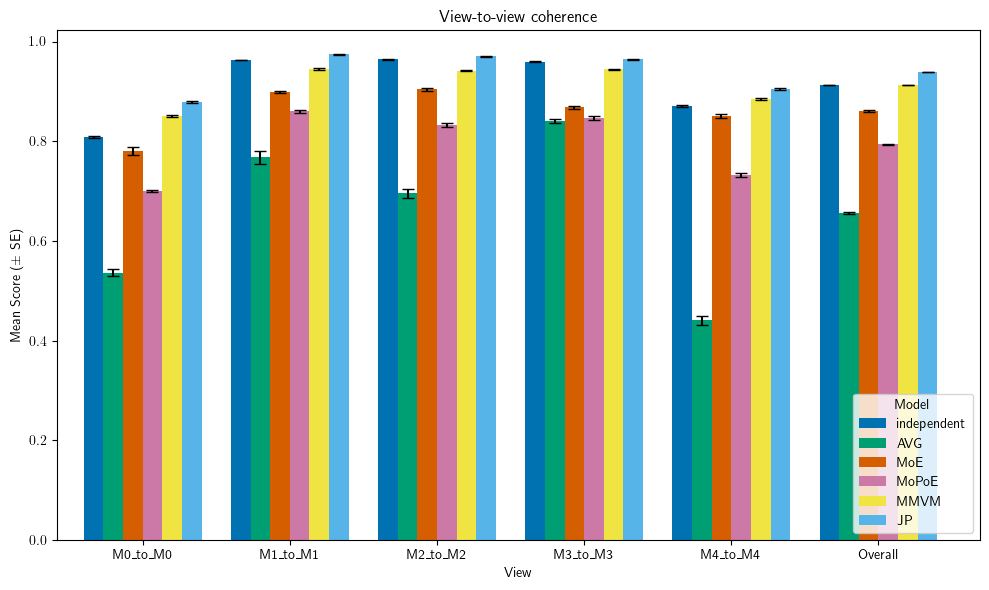

In [220]:
coherence_plots(df_subset, cols_view_to_view, "View", "View-to-view coherence", "results_figures/view_to_view_coherence_barplot.png")

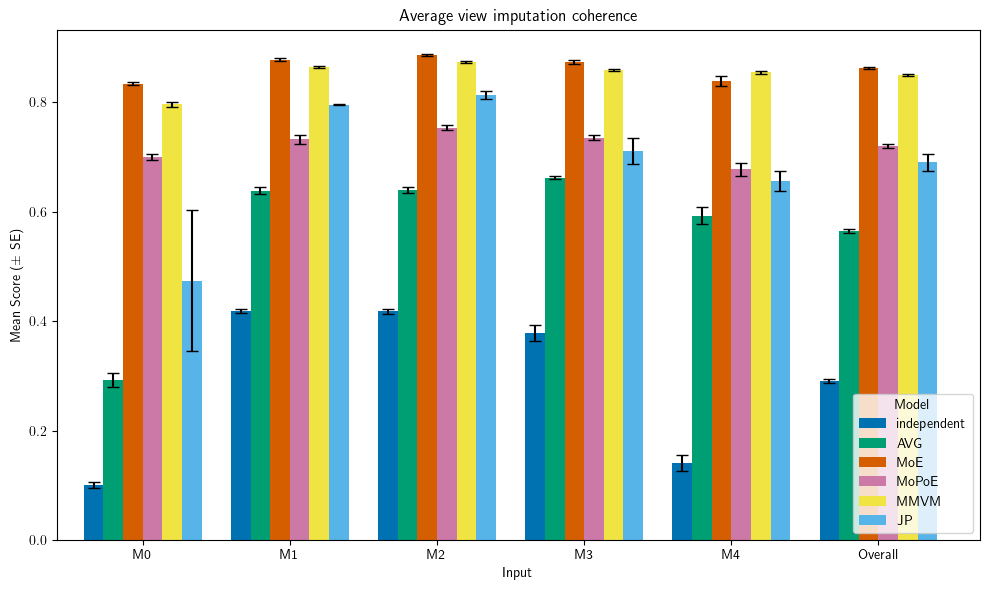

In [221]:
coherence_plots(df_subset, cols_avg, "Input", "Average view imputation coherence", "results_figures/average_imputation_coherence_barplot.png")

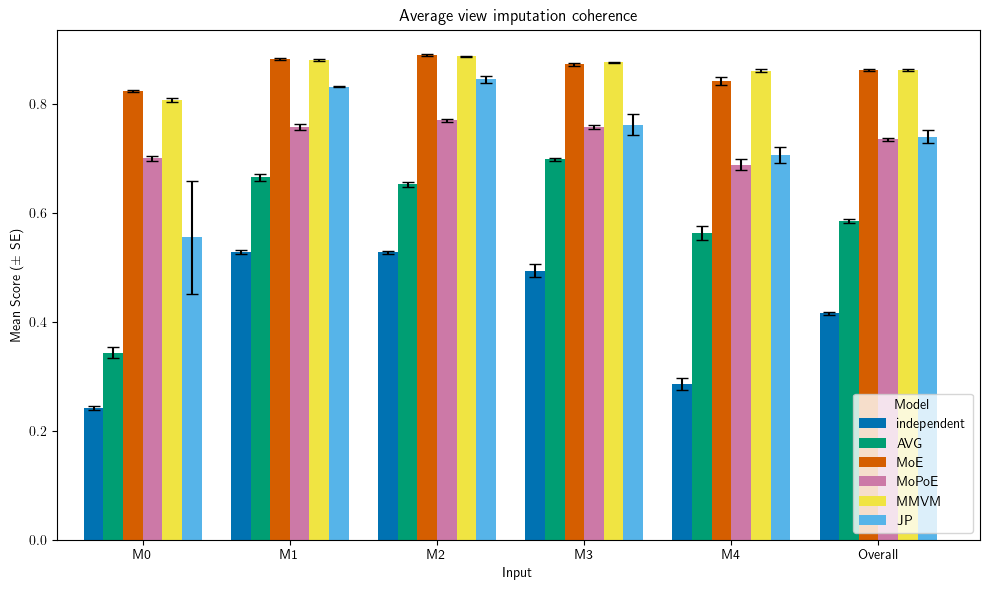

In [223]:
coherence_plots(df_subset, cols_avg_inc_views, "Input", "Average view imputation coherence", "results_figures/average_imputation_coherence_inc_views_barplot.png")

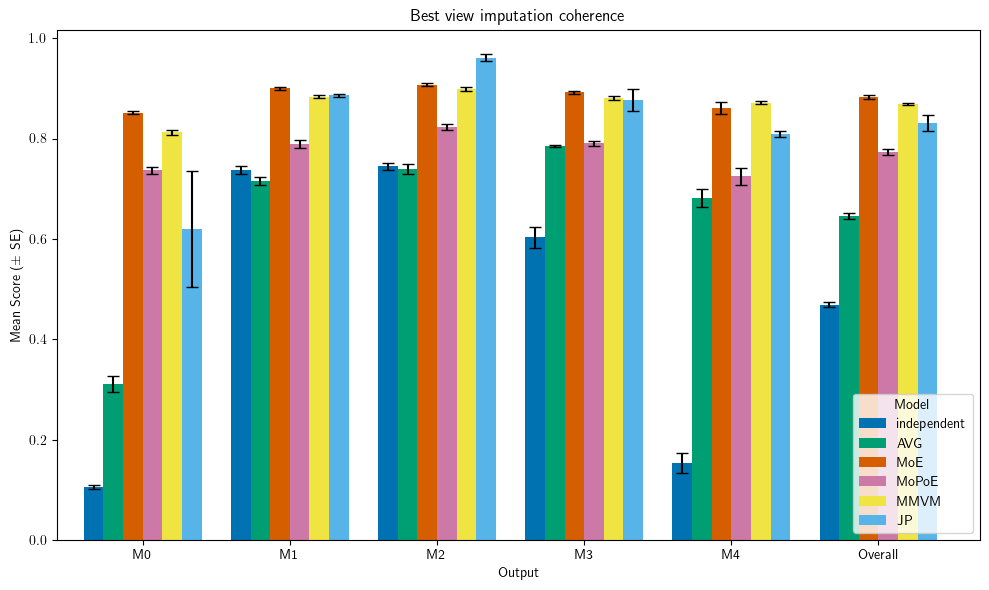

In [224]:
coherence_plots(df_subset, cols_best, "Output", "Best view imputation coherence", "results_figures/best_imputation_coherence_barplot.png")

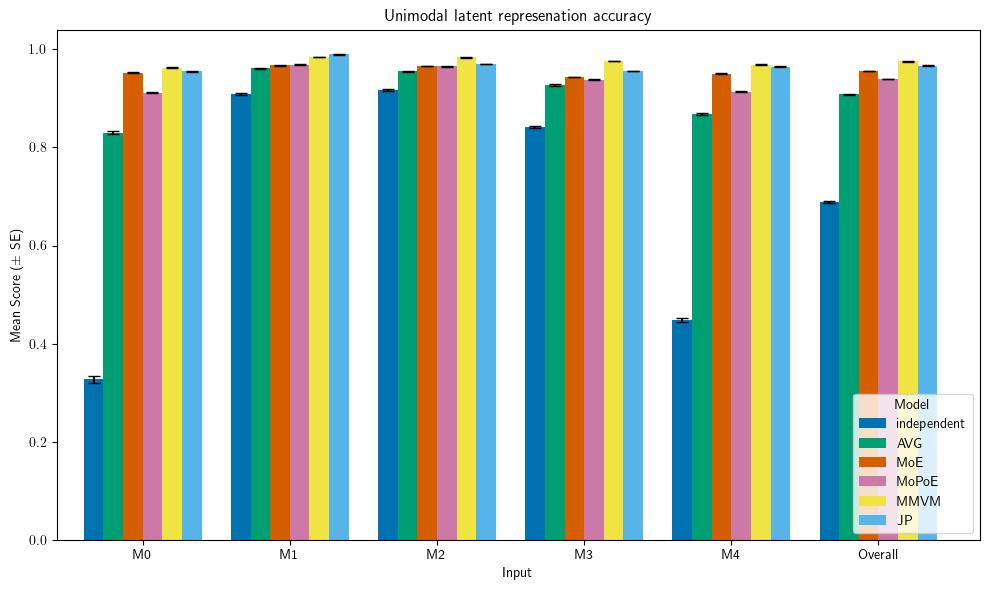

In [225]:
coherence_plots(df_subset, uni_cols, "Input", "Unimodal latent represenation accuracy", "results_figures/unimodal_barplot.png")

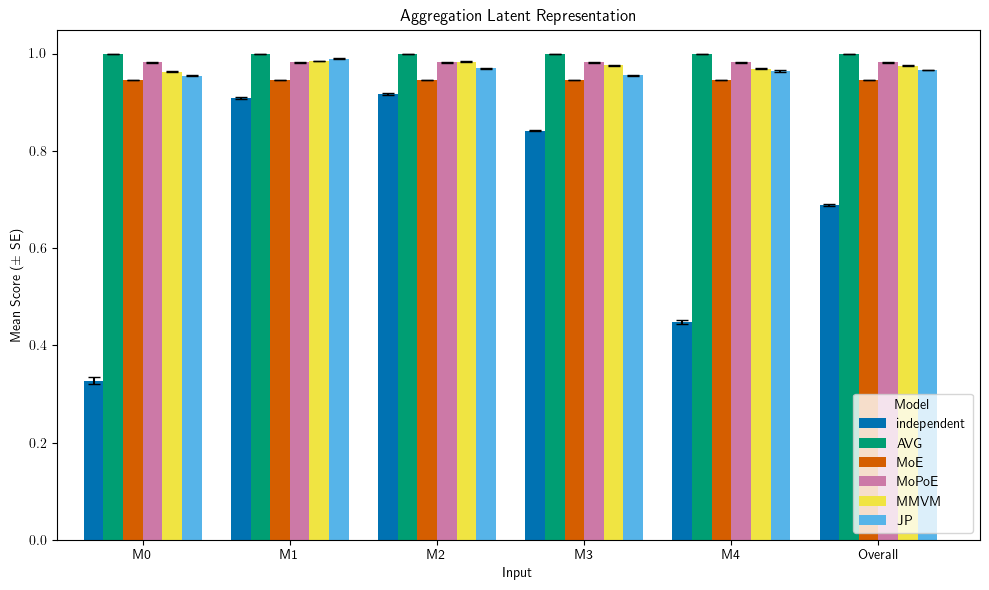

In [226]:
coherence_plots(df_subset, agg_cols, "Input", "Aggregation Latent Representation", "results_figures/agg_barplot.png")

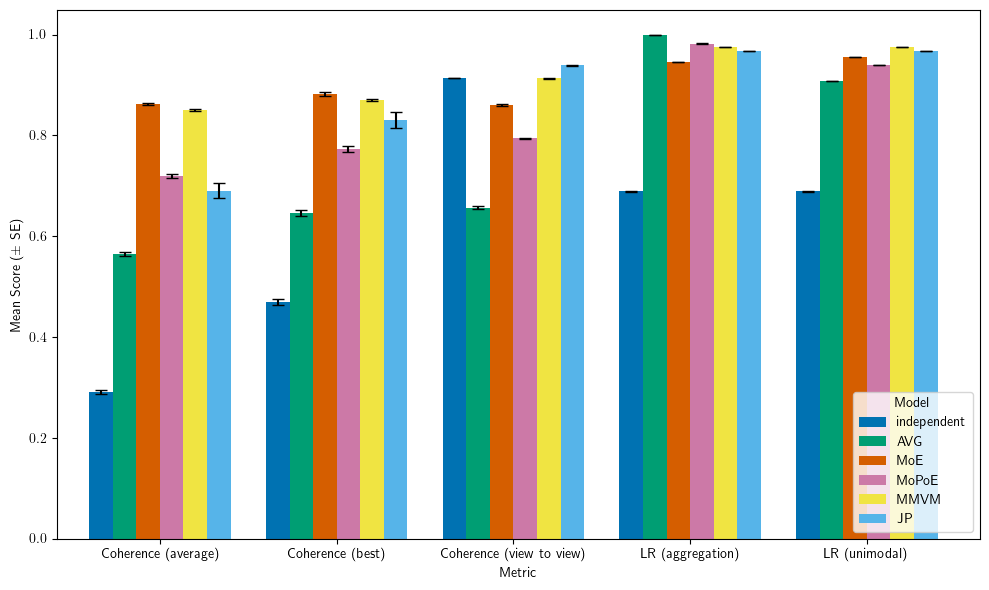

In [227]:
coherence_plots(df_subset, main_cols, "Metric", "", "results_figures/combined_results.png", combination_plot=True)

In [228]:
def two_axis_plot(df, filepath):
  _, axes = plt.subplots(2, 2, figsize=(10,8))
  axes = np.array(axes).reshape(-1)  
  y_axes = ['average_overall', 'best_overall', "agg_average", "unimodal_average"]
  y_titles =["Coherence (average)", "Coherence (best)",
             "Coherence (aggregation)", "LR (unimodal)"]
  for ax, y_axis, y_title in zip(axes, y_axes, y_titles):
    for model, group in df.groupby('model.name', observed=False):
        ax.scatter(
            group["final_scores/rec_loss"],
            group[y_axis],
            label=model,
            alpha=0.8
        )
    ax.set_xlabel("Reconstruction loss", fontsize=10)
    ax.set_ylabel(y_title, fontsize=10)
    if y_title == "LR (unimodal)":
      handles, labels = ax.get_legend_handles_labels()
      by_label = dict(zip(labels, handles))
      ax.legend(by_label.values(), by_label.keys(), title="Model", 
                loc =(0.6, 0.1), scatterpoints=1)
  
  plt.savefig(filepath)
  plt.show()

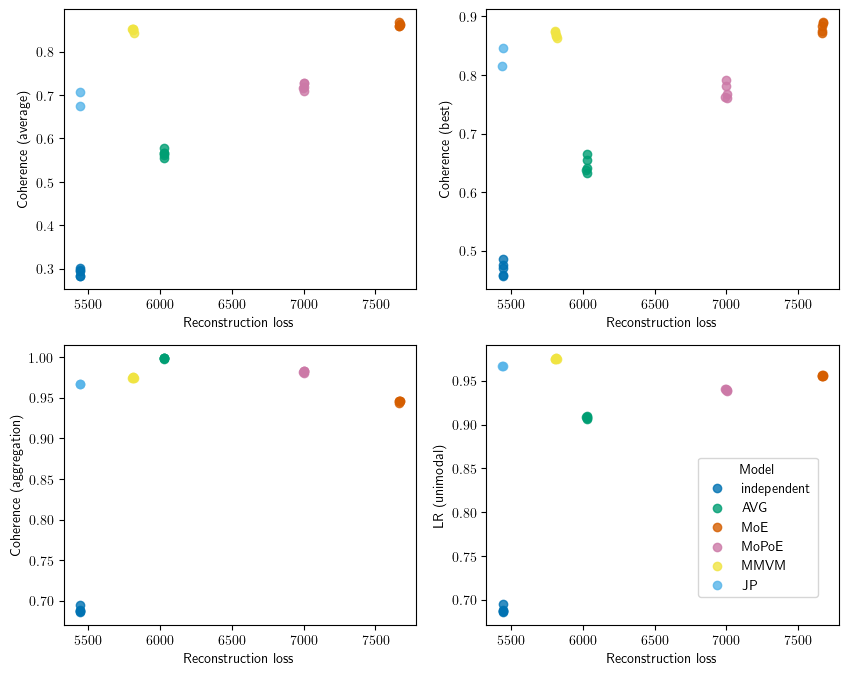

In [229]:
two_axis_plot(df_subset, "results_figures/recon_loss_plots.png")